<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
    
<h1 style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:150%"><b> Table of contents </b></h1>

 - [**Introduction**](#1)

 - [**Import and Set Up**](#2)

 - [**Pre-processing and feature selection**](#3)
    
 - [**Modelling and Evaluation**](#4)
    - [**Logistical Classification**](#4_1)
    - [**kNN**](#4_2)
    - [**Decision Tree**](#4_3)
    - [**Extra Trees**](#4_4)
    - [**Random Forest**](#4_5)
    - [**Gradient Boosting Classifier**](#4_6)
    - [**Neural Network MLP**](#4_7)
    - [**Neural Network MLP (Keras)**](#4_8)
    - [**GRU (Keras)**](#4_9)
    - [**LSTM (Keras)**](#4_10)
    
 - [**Evaluate**](#5)
   

<a id='1'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Introduction</b>

<a id='2'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Import and Set up</b>

### Step 1

This cell imports all required libraries for data manipulation, visualization, and machine learning. It also configures display settings for pandas, matplotlib, and plotly.

In [5]:
import numpy as np
import pandas as pd

from IPython.core.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

pio.renderers.default = 'iframe'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
)

pio.templates.default = 'ck_template+gridon'

### Step 2

This cell mounts Google Drive so the dataset files stored there can be accessed within Colab.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 3

This cell loads the UNSW-NB15 training dataset from Google Drive into a pandas DataFrame called `df`.

In [7]:
df = pd.read_csv(r"/content/drive/MyDrive/El-7areth/attack_detect/data/UNSW_NB15_training-set.csv")

### Step 4

This cell displays a summary of the DataFrame including column names, data types, and non-null counts.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

### Step 5

This cell shows the first 10 rows of the dataset to get a quick look at the data.

In [9]:
df.head(10)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.09020,254,0,1.803636e+08,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.00030,254,0,8.810000e+08,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.00510,254,0,8.544000e+08,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.66080,254,0,6.000000e+08,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.00250,254,0,8.504000e+08,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
5,6,0.000003,udp,-,INT,2,0,784,0,333333.32150,254,0,1.045333e+09,0.0,0,0,0.003,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,392,0,0,0,2,2,2,2,1,2,0,0,0,2,2,0,Normal,0
6,7,0.000006,udp,-,INT,2,0,1960,0,166666.66080,254,0,1.306667e+09,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,980,0,0,0,2,2,2,2,1,2,0,0,0,2,2,0,Normal,0
7,8,0.000028,udp,-,INT,2,0,1384,0,35714.28522,254,0,1.977143e+08,0.0,0,0,0.028,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,692,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
8,9,0.000000,arp,-,INT,1,0,46,0,0.00000,0,0,0.000000e+00,0.0,0,0,60000.688,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,46,0,0,0,2,2,2,2,2,2,0,0,0,2,2,1,Normal,0
9,10,0.000000,arp,-,INT,1,0,46,0,0.00000,0,0,0.000000e+00,0.0,0,0,60000.712,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,46,0,0,0,2,2,2,2,2,2,0,0,0,2,2,1,Normal,0


### Step 6

This cell generates descriptive statistics for all columns, including counts, means, and unique values.

In [10]:
df.describe(include='all')

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,82332.000000,82332.000000,82332,82332,82332,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.00000,8.233200e+04,8.233200e+04,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332,82332.000000
unique,NaN,NaN,131,13,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN
top,NaN,NaN,tcp,-,FIN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,NaN
freq,NaN,NaN,43095,47153,39339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37000,NaN
mean,41166.500000,1.006756,NaN,NaN,NaN,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,4.753692,6.308556,755.394301,121.701284,6.363075e+03,535.180430,133.45908,1.084642e+09,1.073465e+09,128.28662,0.055925,0.029256,0.026669,139.528604,116.275069,0.094277,1.595372e+03,9.546604,1.369273,5.744923,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,NaN,0.550600
std,23767.345519,4.710444,NaN,NaN,NaN,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,64.649620,55.708021,6182.615732,1292.378499,5.672402e+04,3635.305383,127.35700,1.390860e+09,1.381996e+09,127.49137,0.116022,0.070854,0.055094,208.472063,244.600271,0.542922,3.806697e+04,11.090289,1.067188,8.418112,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,NaN,0.497436
min,1.000000,0.000000,NaN,NaN,NaN,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
25%,20583.750000,0.000008,NaN,NaN,NaN,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,NaN,0.000000
50%,41166.500000,0.014138,NaN,NaN,NaN,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,1.000000,0.000000,0.557929,0.010000,1.762392e+01,0.000000,255.00000,2.788886e+07,2.856975e+07,255.00000,0.000551,0.000441,0.000080,65.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,NaN,1.000000
75%,61749.250000,0.719360,NaN,NaN,NaN,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,3.000000,2.000000,63.409444,63.136369,3.219332e+03,128.459914,255.00000,2.171310e+09,2.144205e+09,255.00000,0.105541,0.052596,0.048816,100.000000,87.000000,0.

<a id='3'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Pre-processing and Feature Selection</b>

process and select the features in accordance with the recommendations.

## Drop irrelevant or excess feastures

The first feature to drop is 'id'. This feature is an index and not descriptive.

The second feature to drop is 'attack_cat'. This feature is an extension of the target feature, therefore using it will give us 100% predictions but will not give us a generalizable model.

The other features to be dropped are those that were too strongly correlated. In this current version none of them were dropped, as the model is first evaluated to see how well it can perform.

### Step 7

This cell defines the list of columns to be dropped: `id` (just an index) and `attack_cat` (a leaky target extension).

In [11]:
list_drop = ['id','attack_cat']

### Step 8

This cell drops the `id` and `attack_cat` columns from the DataFrame in-place.

In [12]:
df.drop(list_drop,axis=1,inplace=True)

## Apply Clamping

The extreme values should be pruned to reduce the skewness of some distributions. The logic applied here is that the features with a maximum value more than ten times the median value is pruned to the 95th percentile. If the 95th percentile is close to the maximum, then the tail has more interesting information than what we want to discard.

The clamping is also only applied to features with a maximum of more than 10 times the median. This prevents the bimodals and small value distributions from being excessively pruned.  

### Step 9

This cell selects only numeric columns and displays their statistics before applying clamping.

In [13]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.00000,8.233200e+04,8.233200e+04,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,6.305470e+05,4.753692,6.308556,755.394301,121.701284,6.363075e+03,535.180430,133.45908,1.084642e+09,1.073465e+09,128.28662,0.055925,0.029256,0.026669,139.528604,116.275069,0.094277,1.595372e+03,9.546604,1.369273,5.744923,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,2.393001e+06,64.649620,55.708021,6182.615732,1292.378499,5.672402e+04,3635.305383,127.35700,1.390860e+09,1.381996e+09,127.49137,0.116022,0.070854,0.055094,208.472063,244.600271,0.542922,3.806697e+04,11.090289,1.067188,8.418112,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,2.112951e+03,1.000000,0.000000,0.557929,0.010000,1.762392e+01,0.000000,255.00000,2.788886e+07,2.856975e+07,255.00000,0.000551,0.000441,0.000080,65.000000,44.000000,0.000000,0.000000e+00,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,1.585808e+04,3.000000,2.000000,63.409444,63.136369,3.219332e+03,128.459914,255.00000,2.171310e+09,2.144205e+09,255.00000,0.105541,0.052596,0.048816,100.000000,87.000000,0.000000,0.000000e+00,11.000000,2.000000,6.000000,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,2.082111e+07,5319.000000,5507.000000,60009.992000,57739.240000,1.483831e+06,463199.240100,255.00000,4.294950e+09,4.294881e+09,255.00000,3.821465,3.226788,2.928778,1504.000000,1500.000000,131.000000,5.242880e+06,63.000000,6.000000,59.000000,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


### Step 10

This cell applies clamping: for any numeric feature where the max is more than 10× the median, values above the 95th percentile are replaced with that percentile to reduce extreme outliers.

In [14]:
DEBUG =0

for feature in df_numeric.columns:
    if DEBUG == 1:
        print(feature)
        print('max = '+str(df_numeric[feature].max()))
        print('75th = '+str(df_numeric[feature].quantile(0.95)))
        print('median = '+str(df_numeric[feature].median()))
        print(df_numeric[feature].max()>10*df_numeric[feature].median())
        print('----------------------------------------------------')
    if df_numeric[feature].max()>10*df_numeric[feature].median() and df_numeric[feature].max()>10 :
        df[feature] = np.where(df[feature]<df[feature].quantile(0.95), df[feature], df[feature].quantile(0.95))

### Step 11

This cell re-selects numeric columns and displays their statistics after clamping, so you can compare before and after.

### Step 12

This cell applies a log transformation to continuous numeric features (those with more than 50 unique values) to reduce right-skew. It uses `log(x+1)` for features that contain zeros.

In [15]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all')

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.00000,8.233200e+04,8.233200e+04,82332.00000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,0.445016,11.84186,9.178424,1580.566135,2866.918367,71576.702810,180.967667,95.713003,4.649418e+07,3.105380e+05,2.188068,2.542729,37.836042,33.982038,1920.889858,199.566224,133.45908,1.074064e+09,1.062670e+09,128.28662,0.055925,0.029256,0.026669,124.772822,100.240891,0.092091,9.643063,9.259887,1.369273,5.269591,4.466611,3.388901,7.160679,0.008284,0.008381,0.092066,5.974809,8.832532,0.011126,0.550600
std,0.672222,15.66461,14.504212,2948.850472,7525.606738,102631.946851,101.513358,116.667722,7.417784e+07,8.918691e+05,3.057946,4.767511,57.658385,52.184248,2900.509949,520.285264,127.35700,1.368335e+09,1.358850e+09,127.49137,0.116022,0.070854,0.055094,148.294212,184.094183,0.289156,35.977508,10.221752,1.067188,6.729755,6.685037,5.029129,10.481621,0.091171,0.092485,0.289121,6.867156,10.124902,0.104891,0.497436
min,0.000000,1.00000,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000008,2.00000,0.000000,114.000000,0.000000,28.606114,62.000000,0.000000,1.120247e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000,0.000000,0.00000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,0.014138,6.00000,2.000000,534.000000,178.000000,2650.176667,254.000000,29.000000,5.770032e+05,2.112951e+03,1.000000,0.000000,0.557929,0.010000,17.623918,0.000000,255.00000,2.788886e+07,2.856975e+07,255.00000,0.000551,0.000441,0.000080,65.000000,44.000000,0.000000,0.000000,5.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,0.719360,12.00000,10.000000,1280.000000,956.000000,111111.107200,254.000000,252.000000,6.514286e+07,1.585808e+04,3.000000,2.000000,63.409444,63.136369,3219.332412,128.459914,255.00000,2.171310e+09,2.144205e+09,255.00000,0.105541,0.052596,0.048816,100.000000,87.000000,0.000000,0.000000,11.000000,2.000000,6.000000,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,2.403792,60.00000,54.000000,12472.000000,30622.000000,333333.321500,255.000000,253.000000,2.666667e+08,3.741446e+06,11.000000,18.000000,204.530258,167.626851,9532.382646,2218.933526,255.00000,3.876194e+09,3.862459e+09,255.00000,3.821465,3.226788,2.928778,638.000000,683.000000,1.000000,150.450000,37.000000,6.000000,25.000000,25.000000,18.000000,37.000000,2.000000,2.000000,1.000000,25.000000,36.000000,1.000000,1.000000


## Apply log function to nearly all numeric, since they are all mostly skewed to the right

It would have been too much of a slog to apply the log function individually, therefore a simple rule has been set up: if the number of unique values in the continuous feature is more than 50 then apply the log function. The reason more than 50 unique values are sought is to filter out the integer based features that act more categorically.  

### Step 13

This cell selects only categorical (non-numeric) columns and shows their statistics.

In [16]:
df_numeric = df.select_dtypes(include=[np.number])
df_before = df_numeric.copy()
DEBUG = 0
for feature in df_numeric.columns:
    if DEBUG == 1:
        print(feature)
        print('nunique = '+str(df_numeric[feature].nunique()))
        print(df_numeric[feature].nunique()>50)
        print('----------------------------------------------------')
    if df_numeric[feature].nunique()>50:
        if df_numeric[feature].min()==0:
            df[feature] = np.log(df[feature]+1)
        else:
            df[feature] = np.log(df[feature])

df_numeric = df.select_dtypes(include=[np.number])

## Reduce the labels in catagorical features

Some features have very high cardinalities, and this section reduces the cardinality to 5 or 6 per feature. The logic is to take the top 5 occuring labels in the feature as the labels and set the remainder to '-' (seldom used) labels. When the encoding is done later on, the dimensionality will not explode and cause the curse of dimensionality.

### Step 14

This cell reduces the cardinality of high-cardinality categorical features: only the top 5 most frequent labels are kept; all others are replaced with `'-'`.

In [17]:
df_cat = df.select_dtypes(exclude=[np.number])
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,131,13,7
top,tcp,-,FIN
freq,43095,47153,39339


### Step 15

This cell re-checks the categorical columns after label reduction to confirm the cardinality has been reduced.

In [18]:
DEBUG = 0
for feature in df_cat.columns:
    if DEBUG == 1:
        print(feature)
        print('nunique = '+str(df_cat[feature].nunique()))
        print(df_cat[feature].nunique()>6)
        print(sum(df[feature].isin(df[feature].value_counts().head().index)))
        print('----------------------------------------------------')

    if df_cat[feature].nunique()>6:
        df[feature] = np.where(df[feature].isin(df[feature].value_counts().head().index), df[feature], '-')

### Step 16

This cell shows the top occurring values in the `proto` column.

In [19]:
df_cat = df.select_dtypes(exclude=[np.number])
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


### Step 17

This cell shows all unique values in the `proto` column.

In [20]:
df['proto'].value_counts().head().index

Index(['tcp', 'udp', '-', 'unas', 'arp'], dtype='object', name='proto')

### Step 18

This cell performs univariate feature selection using the Chi-squared test to rank features by their statistical relationship with the target variable, and plots the top 20.

In [21]:
df['proto'].value_counts().index

Index(['tcp', 'udp', '-', 'unas', 'arp', 'ospf'], dtype='object', name='proto')

## View before and after of features

This section simply displays the distributions within features before and after the transformations.  

## Best Features

This section does an analysis (univariate statistical tests) to determine which features best predict the target feature.

### Step 19

This cell separates the features (`X`) from the target variable (`y`) using the last column as the label.

In [22]:
from sklearn.feature_selection import SelectKBest, chi2

best_features = SelectKBest(score_func=chi2,k='all')

X = df.iloc[:,4:-2]
y = df.iloc[:,-1]
fit = best_features.fit(X,y)

df_scores=pd.DataFrame(fit.scores_)
df_col=pd.DataFrame(X.columns)

feature_score=pd.concat([df_col,df_scores],axis=1)
feature_score.columns=['feature','score']
feature_score.sort_values(by=['score'],ascending=True,inplace=True)

fig = go.Figure(go.Bar(
            x=feature_score['score'][0:21],
            y=feature_score['feature'][0:21],
            orientation='h'))

fig.update_layout(title="Top 20 Features",
                  height=1200,
                  showlegend=False,
                 )

fig.show()

## Encode categorical features

The categorical features must be encoded to ensure that the models can interpret them. One-hot encoding is used since none of the categorical features are ordinal.  

### Step 20

This cell previews the feature matrix and stores column names for later reference.

In [23]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

### Step 21

This cell applies One-Hot Encoding to the three categorical columns (proto, service, state) using `ColumnTransformer`, and converts the result to a NumPy array.

In [24]:
X.head()
feature_names = list(X.columns)
np.shape(X)

(82332, 42)

### Step 22

This cell checks the new shape of `X` after One-Hot Encoding to confirm the number of columns has changed.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1,2,3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

### Step 23

This cell re-displays categorical statistics for reference.

In [26]:
np.shape(X)

(82332, 56)

### Step 24

This cell inspects the first encoded sample in `X`.

In [27]:
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


### Step 25

This cell checks the original number of feature names before adding the encoded category names.

In [28]:
X[0]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
       0.00000000e+00, 1.09999395e-05, 6.93147181e-01, 0.00000000e+00,
       6.20657593e+00, 0.00000000e+00, 1.14176263e+01, 2.54000000e+02,
       0.00000000e+00, 1.90104856e+01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.09399400e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       5.51342875e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.00000000e+00, 2.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 2.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.00000000e+00, 2.00000000e+00, 0.00000000e+00])

### Step 26

This cell prepends the One-Hot Encoded category labels for `state`, `service`, and `proto` into the `feature_names` list to keep track of all feature names.

In [29]:
len(feature_names)

42

### Step 27

This cell checks the total number of feature names after adding the encoded labels.

In [30]:
for label in list(df_cat['state'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

for label in list(df_cat['service'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

for label in list(df_cat['proto'].value_counts().index)[::-1][1:]:
    feature_names.insert(0,label)

### Step 28

This cell splits the data into training and test sets (80/20 split) using stratified sampling to preserve the class distribution.

In [31]:
len(feature_names)

56

<a id='4'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Modelling and Evaluation</b>

## Prep for Modelling

### Split test and training
In this section the data is split into test and training sets using stratified sampling.

### Step 29

This cell re-displays categorical statistics for reference.

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 0,
                                                    stratify=y)

### Standardize continuous features
a standard scaler is used on the continuous features to put them all in the same order of size.

### Step 30

This cell applies `StandardScaler` to the continuous features (columns 18 onwards) so they are all on the same scale. The scaler is fitted on training data only and applied to both train and test.

In [33]:
df_cat.describe(include='all')

,proto,service,state
count,82332,82332,82332
unique,6,5,6
top,tcp,-,FIN
freq,43095,49275,39339


### Step 31

This cell imports the evaluation metrics (accuracy, recall, precision, F1-score, confusion matrix) and initializes a DataFrame to store each model's performance results.

In [34]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:, 18:] = sc.fit_transform(X_train[:, 18:])
X_test[:, 18:] = sc.transform(X_test[:, 18:])

### Import Metrics

Imports the libraries that will be used to evaluate the models later on

### Step 32

This cell trains a Logistic Regression model on the training data, records training and prediction times.

In [35]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import time
import pandas as pd

model_performance = pd.DataFrame(columns=['Accuracy', 'Train Accuracy', 'Recall', 'Precision', 'F1-Score', 'time to train', 'time to predict', 'total time'])

<a id='4_1'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Logistical Classification</b>

### Step 33

This cell computes and prints accuracy, recall, precision, and F1-score for the Logistic Regression model, and saves the results to the `model_performance` table.

In [36]:
%%time
from sklearn.linear_model import LogisticRegression
start = time.time()
model = LogisticRegression().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 3.94 s, sys: 0 ns, total: 3.94 s
Wall time: 2.05 s


### Step 34

This cell imports plotting libraries needed to display the confusion matrix.

In [37]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Logistic'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 92.88%
Train Accuracy: 92.62%
Recall: 92.88%
Precision: 92.91%
F1-Score: 92.88%
time to train: 2.04 s
time to predict: 0.01 s
total: 2.05 s


### Step 35

This cell generates and displays the confusion matrix for the Logistic Regression model using a blue color map.

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

### Step 36

This cell saves the trained Logistic Regression model to Google Drive using joblib.

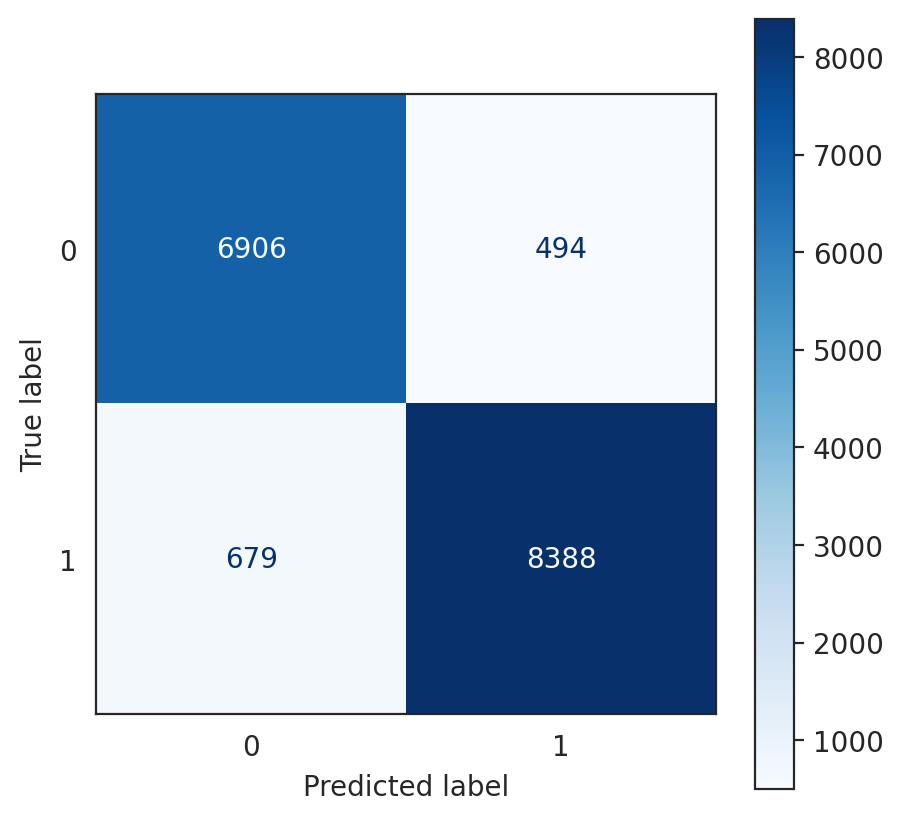

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 37

This cell trains a K-Nearest Neighbors (kNN) classifier with k=3 and records the training and prediction times.

In [40]:
import joblib

joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/logistic_regression_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/logistic_regression_model.pkl']

<a id='4_2'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>kNN</b>

### Step 38

This cell computes and prints evaluation metrics for the kNN model and saves them to the performance table.

In [41]:
%%time
from sklearn.neighbors import KNeighborsClassifier
start = time.time()
model = KNeighborsClassifier(n_neighbors=3).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 12.7 s, sys: 14.7 ms, total: 12.7 s
Wall time: 13.2 s


### Step 39

This cell displays the confusion matrix for the kNN model.

In [42]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['kNN'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 95.04%
Train Accuracy: 97.44%
Recall: 95.04%
Precision: 95.09%
F1-Score: 95.05%
time to train: 0.01 s
time to predict: 13.17 s
total: 13.17 s


### Step 40

This cell re-trains the kNN model and saves it to Google Drive.

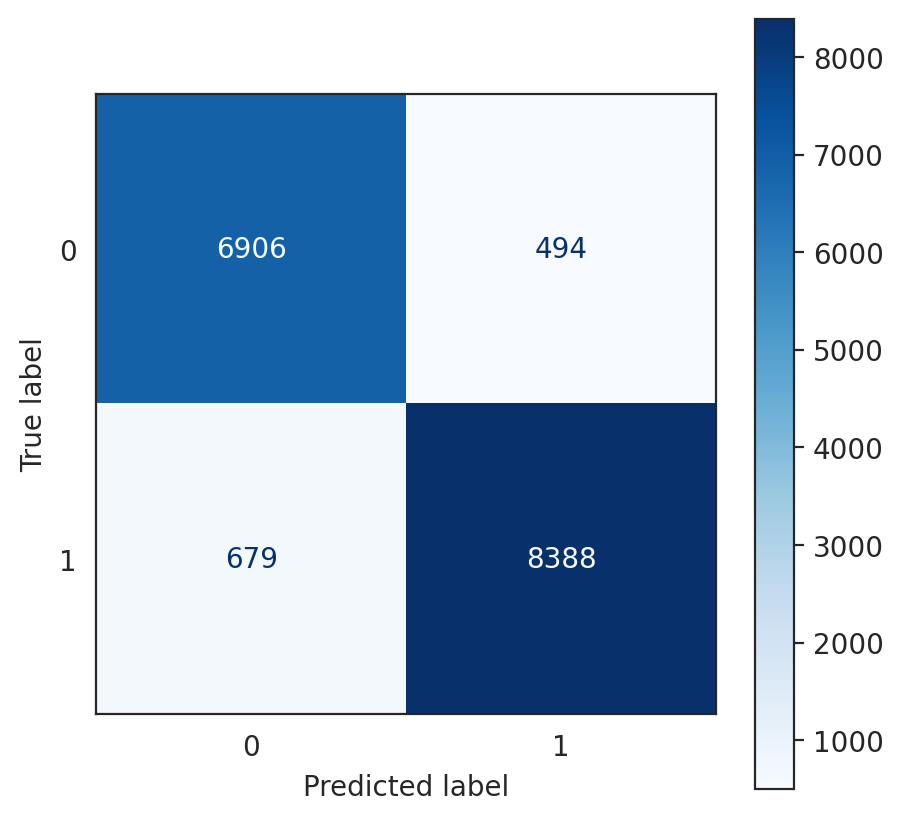

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 41

This cell trains a Decision Tree classifier and records the timing.

In [44]:
import joblib
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

joblib.dump(model, '/content/drive/MyDrive/El-7areth/attack_detect/مودل/knn_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/knn_model.pkl']

<a id='4_3'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Decision Tree</b>


### Step 42

This cell computes and prints evaluation metrics for the Decision Tree and saves them to the performance table.

In [45]:
%%time
from sklearn.tree import DecisionTreeClassifier
start = time.time()
model = DecisionTreeClassifier().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 2.2 s, sys: 4.72 ms, total: 2.2 s
Wall time: 2.3 s


### Step 43

This cell displays the confusion matrix for the Decision Tree model.

In [46]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Decision Tree'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 96.47%
Train Accuracy: 99.99%
Recall: 96.47%
Precision: 96.47%
F1-Score: 96.47%
time to train: 2.21 s
time to predict: 0.00 s
total: 2.21 s


### Step 44

This cell plots the top 20 most important features according to the Decision Tree.

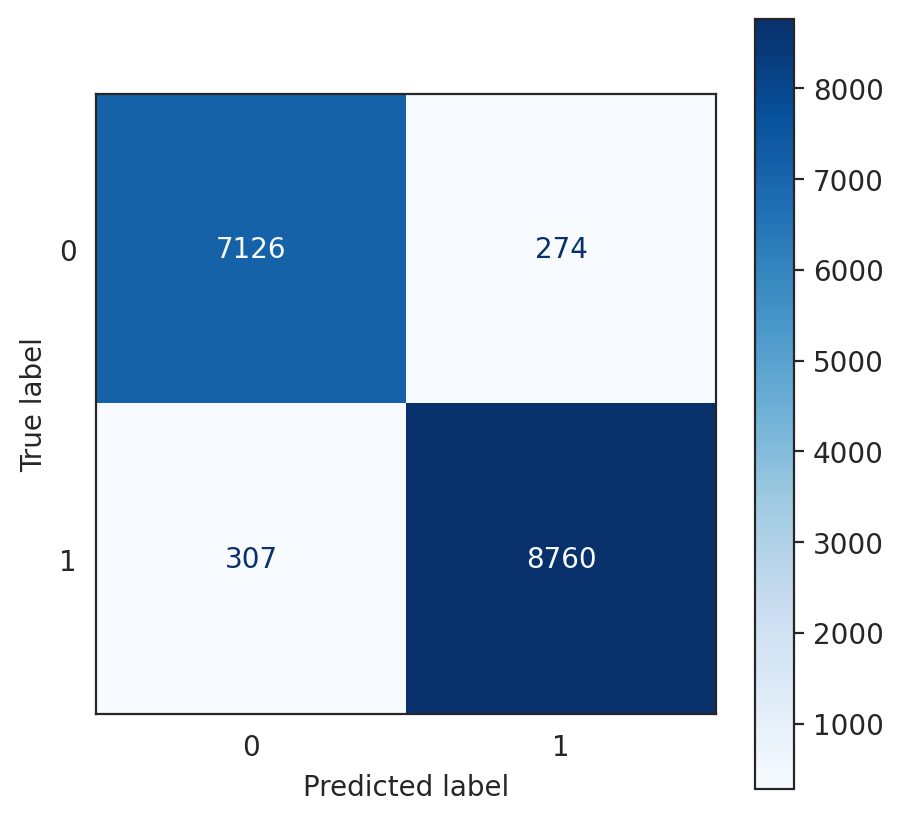

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 45

This cell saves the Decision Tree model to Google Drive.

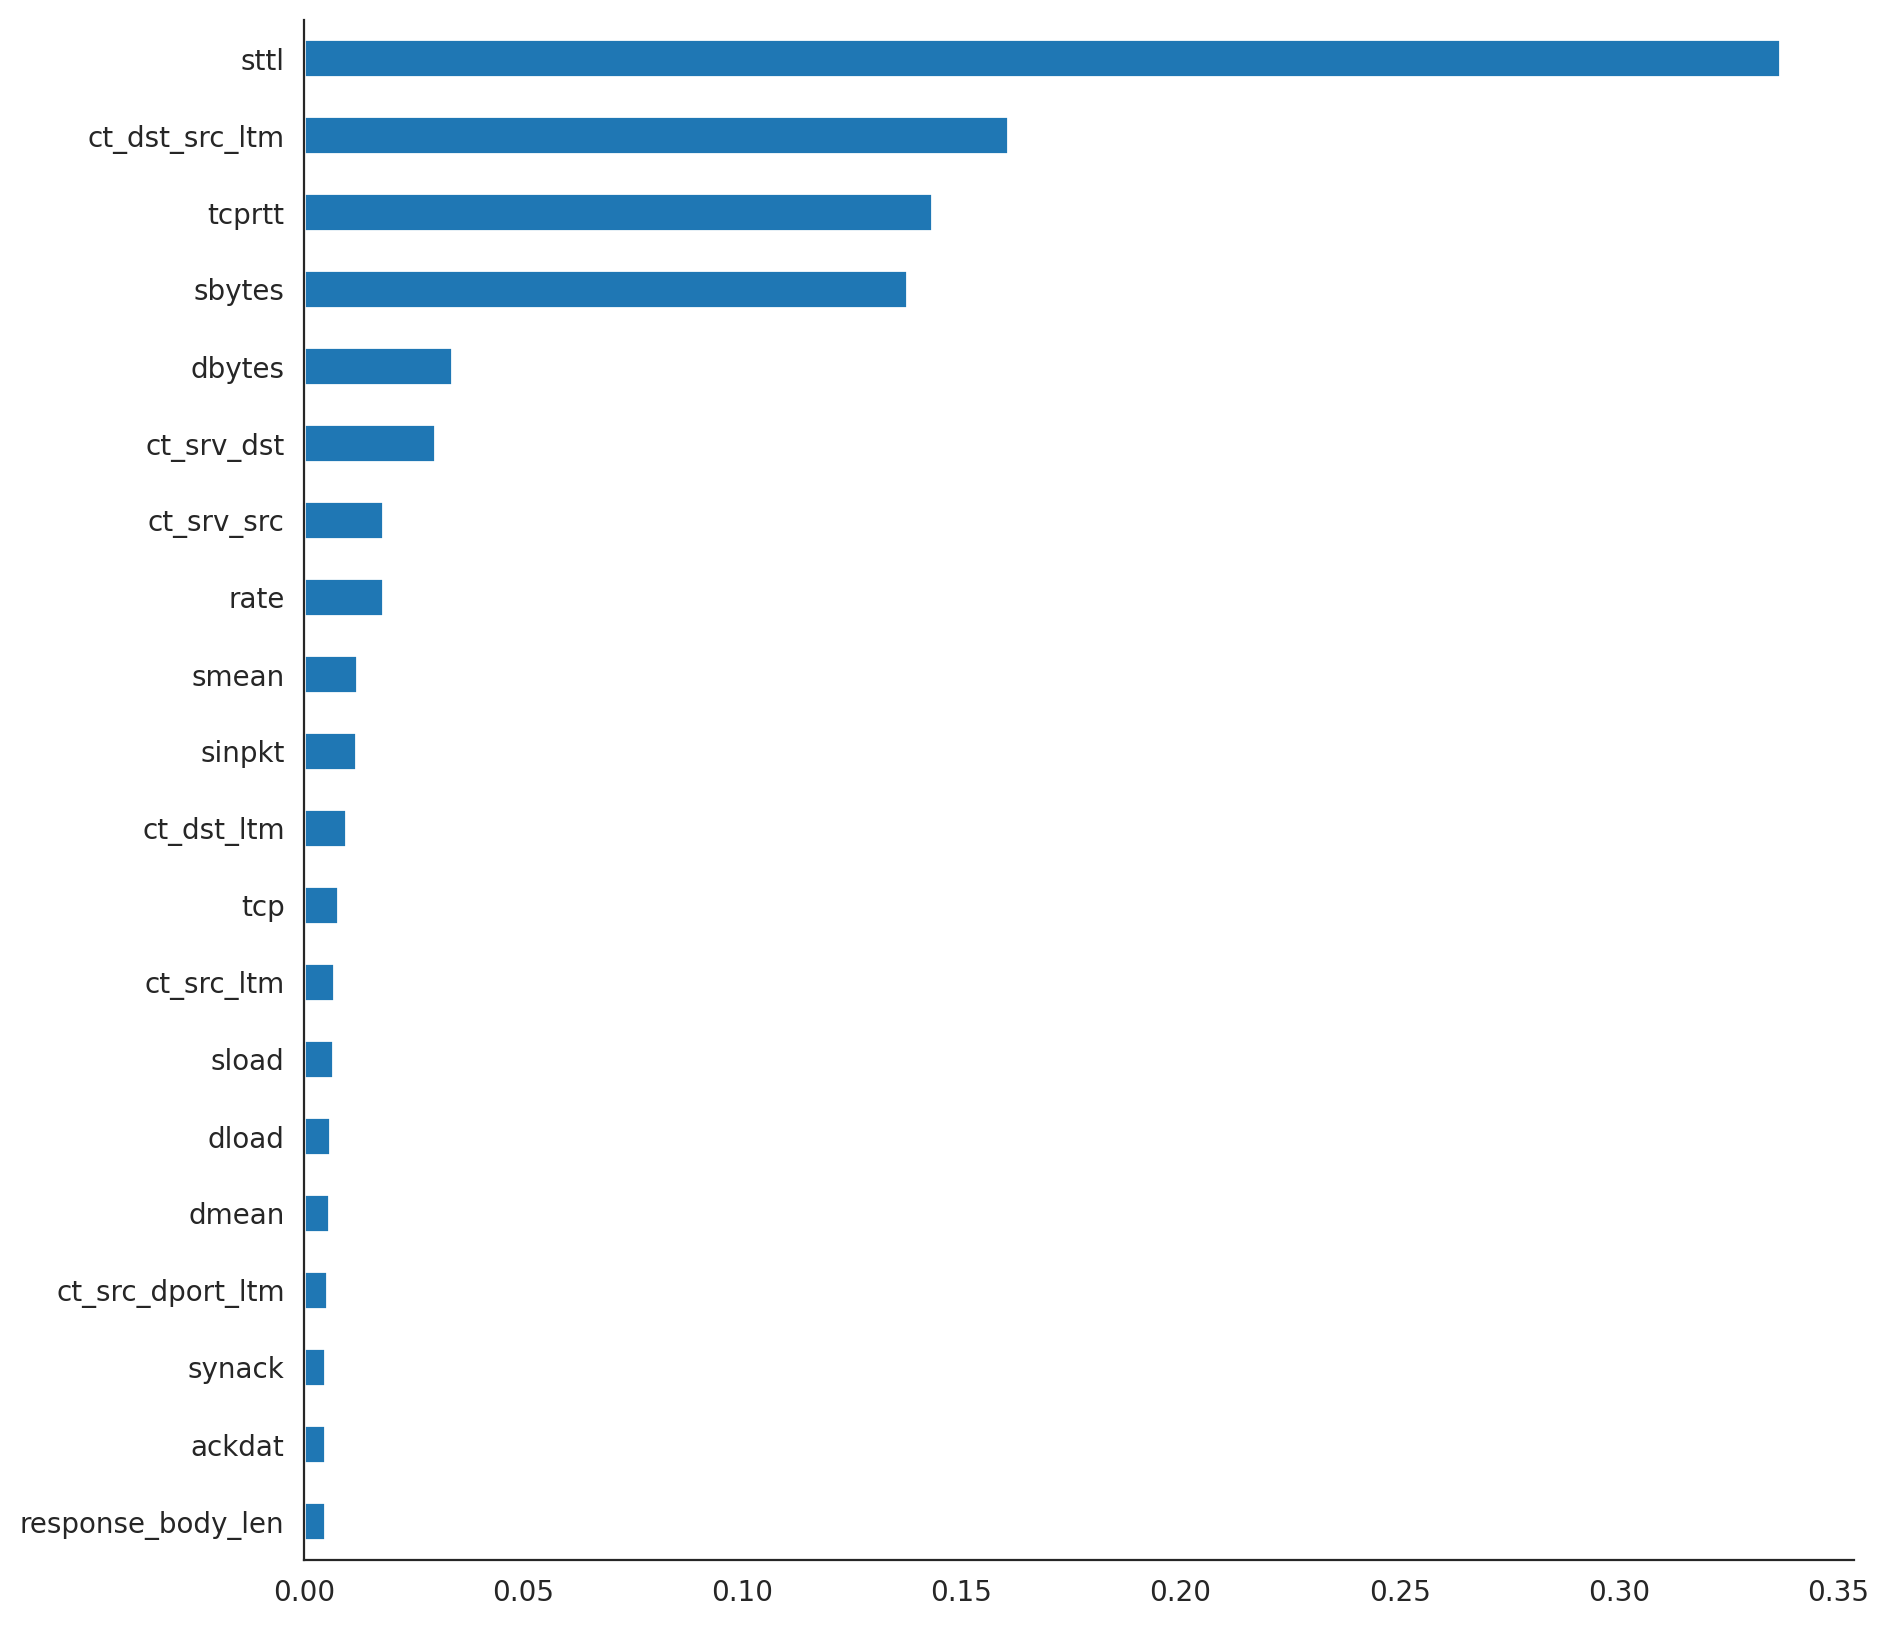

In [48]:
plt.rcParams['figure.figsize']=10,10
sns.set_style("white")
feat_importances = pd.Series(model.feature_importances_, index=feature_names)
feat_importances = feat_importances.groupby(level=0).mean()
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()
sns.despine()
plt.show()

### Step 46

This cell trains an Extra Trees classifier (an ensemble of randomized decision trees) and records the timing.

In [49]:
joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/decision_tree_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/decision_tree_model.pkl']

<a id='4_4'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Extra Trees</b>

### Step 47

This cell computes and prints evaluation metrics for the Extra Trees model.

In [50]:
%%time
from sklearn.ensemble import ExtraTreesClassifier
start = time.time()
model = ExtraTreesClassifier(random_state=0,n_jobs=-1).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 9.64 s, sys: 108 ms, total: 9.75 s
Wall time: 5.18 s


### Step 48

This cell displays the confusion matrix for the Extra Trees model.

In [51]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Extra Trees'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 97.53%
Train Accuracy: 99.99%
Recall: 97.53%
Precision: 97.55%
F1-Score: 97.53%
time to train: 4.83 s
time to predict: 0.21 s
total: 5.04 s


### Step 49

This cell plots the top 20 most important features according to the Extra Trees model.

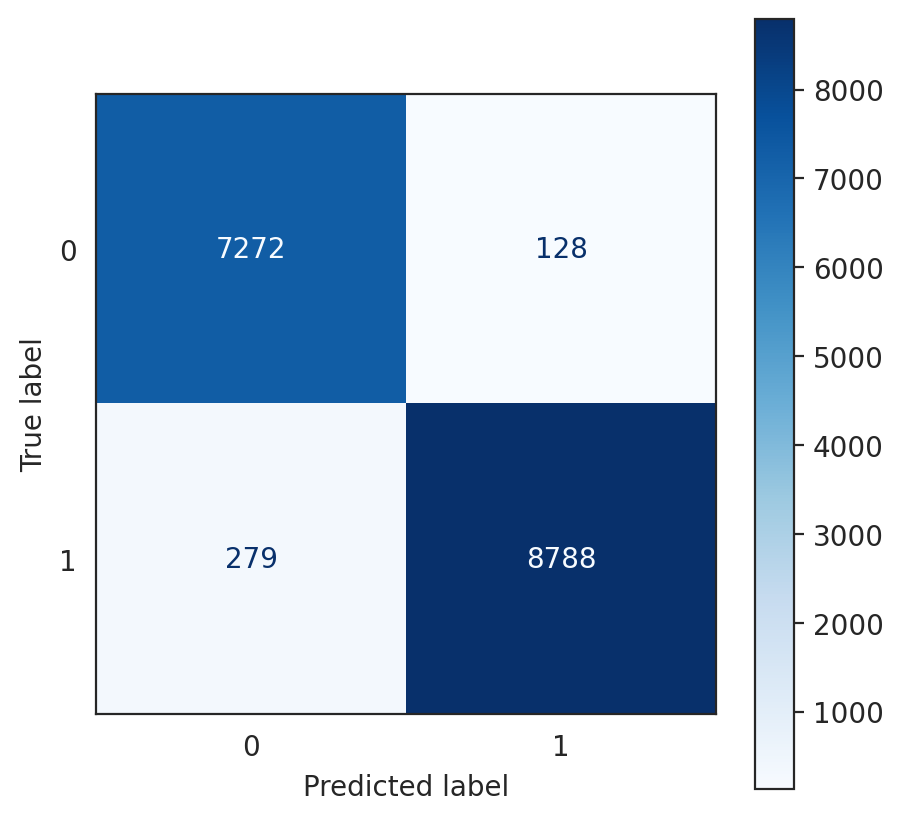

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 50

This cell saves the Extra Trees model to Google Drive.

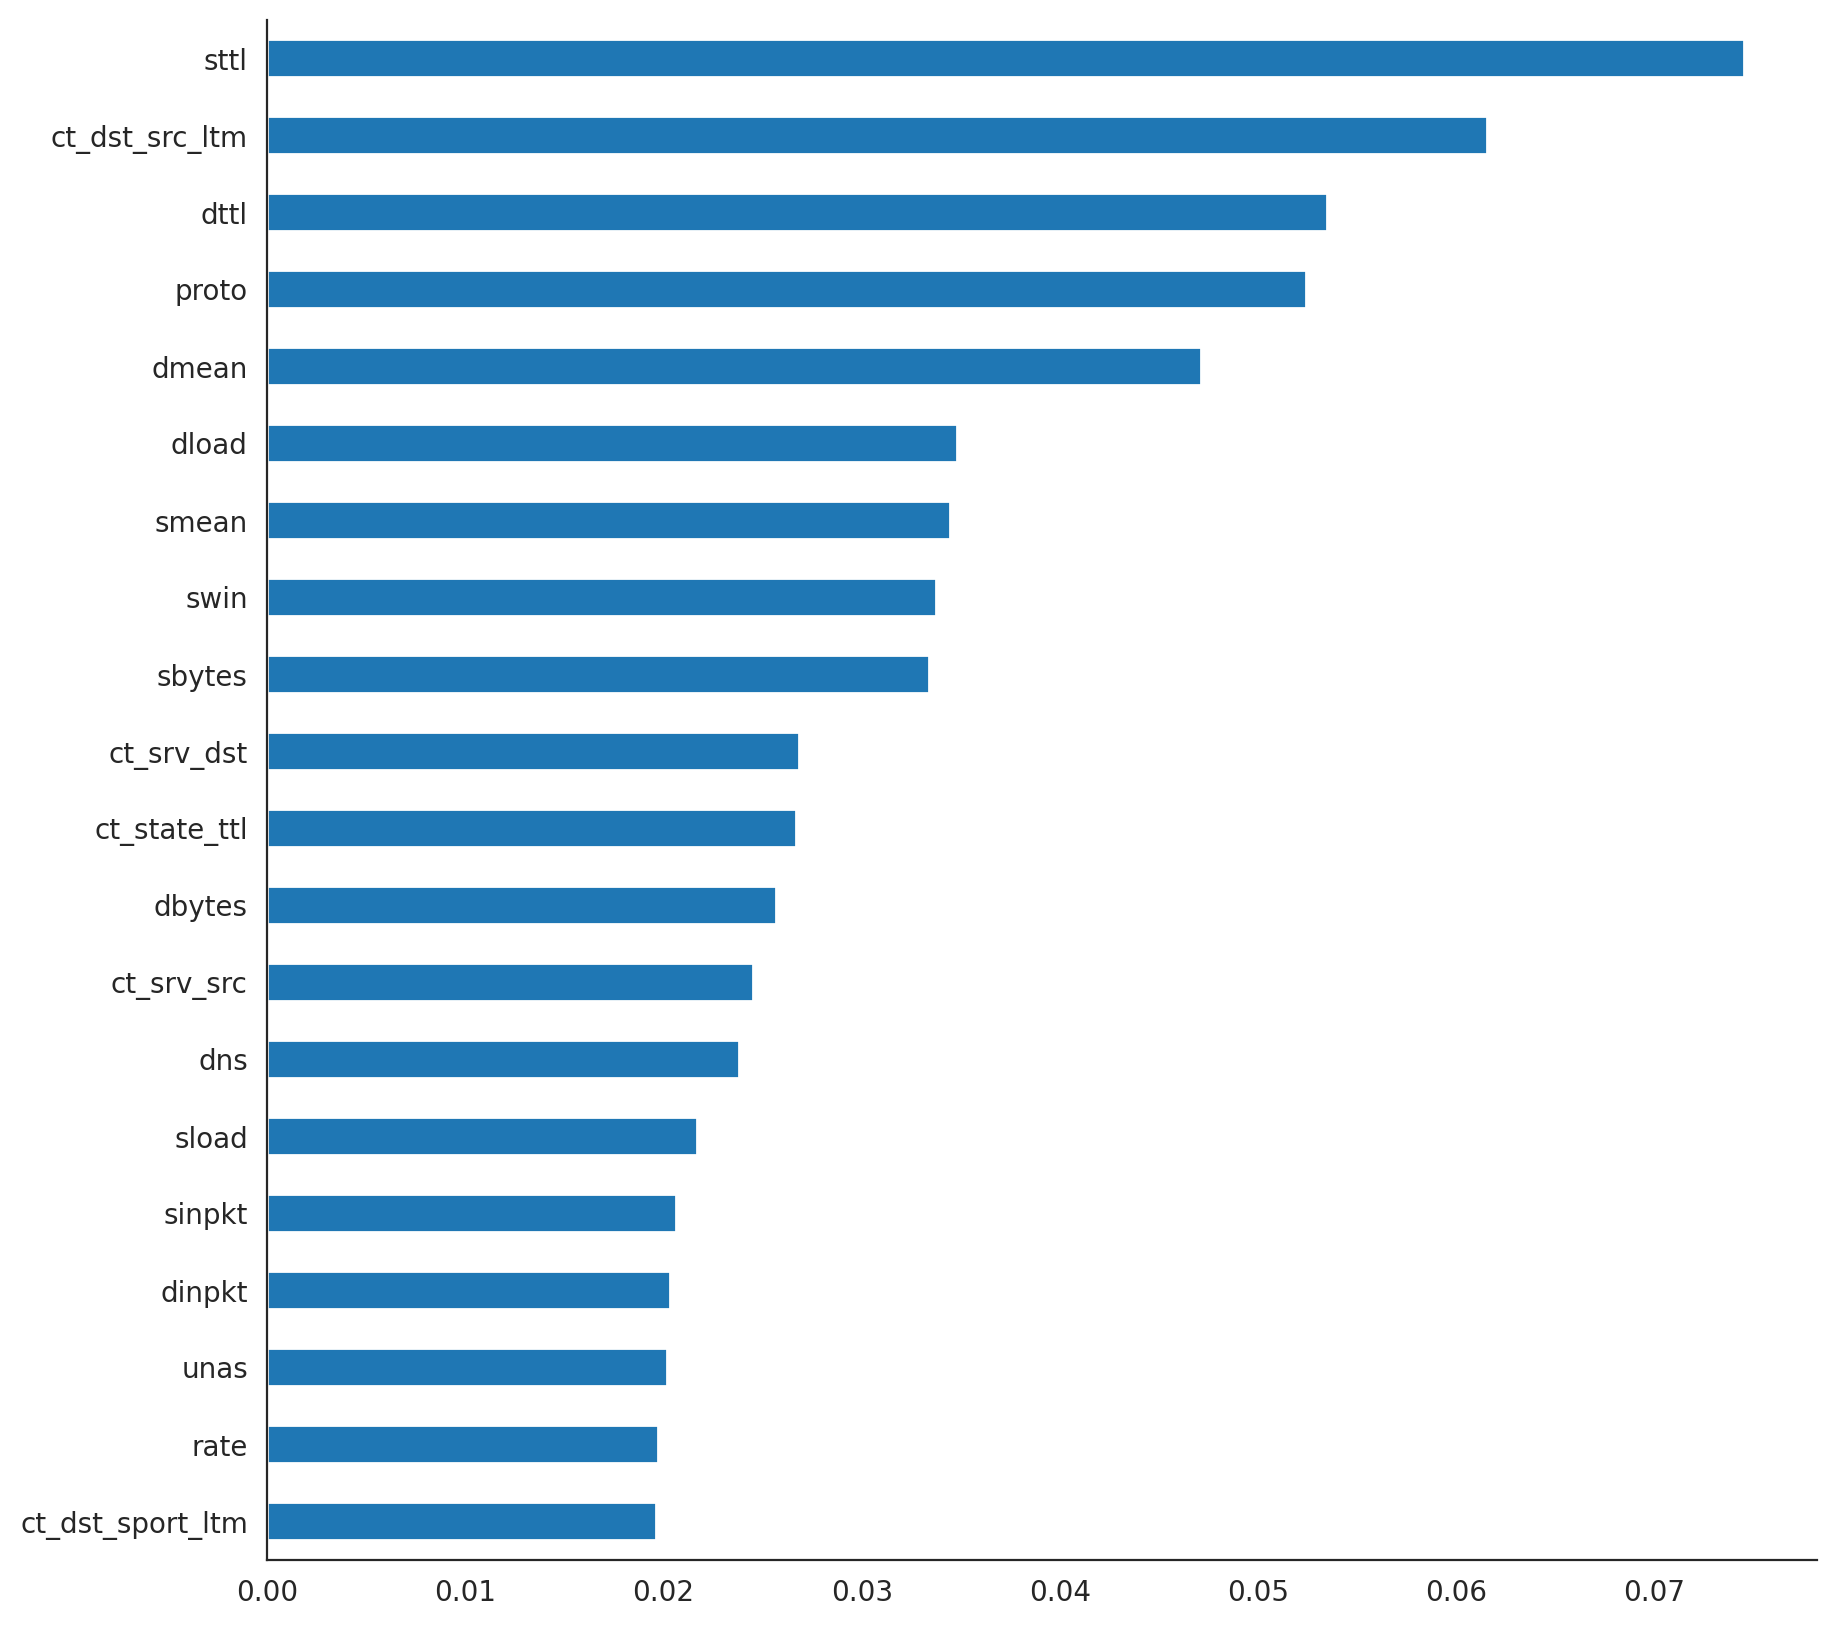

In [53]:
plt.rcParams['figure.figsize']=10,10
sns.set_style("white")
sns.despine()
feat_importances = pd.Series(model.feature_importances_, index=feature_names)
feat_importances = feat_importances.groupby(level=0).mean()
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()
sns.despine()
plt.show()

### Step 51

This cell trains a Random Forest classifier with 100 trees and records the timing.

In [54]:
joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/extra_trees_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/extra_trees_model.pkl']

<a id='4_5'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Random Forest</b>

### Step 52

This cell computes and prints evaluation metrics for the Random Forest model.

In [55]:
%%time
from sklearn.ensemble import RandomForestClassifier
start = time.time()
model = RandomForestClassifier(n_estimators = 100,n_jobs=-1,random_state=0,bootstrap=True,).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 22.9 s, sys: 81.9 ms, total: 23 s
Wall time: 15 s


### Step 53

This cell displays the confusion matrix for the Random Forest model.

In [56]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Random Forest'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 97.67%
Train Accuracy: 99.99%
Recall: 97.67%
Precision: 97.68%
F1-Score: 97.67%
time to train: 14.84 s
time to predict: 0.16 s
total: 15.00 s


### Step 54

This cell plots the top 20 most important features according to the Random Forest.

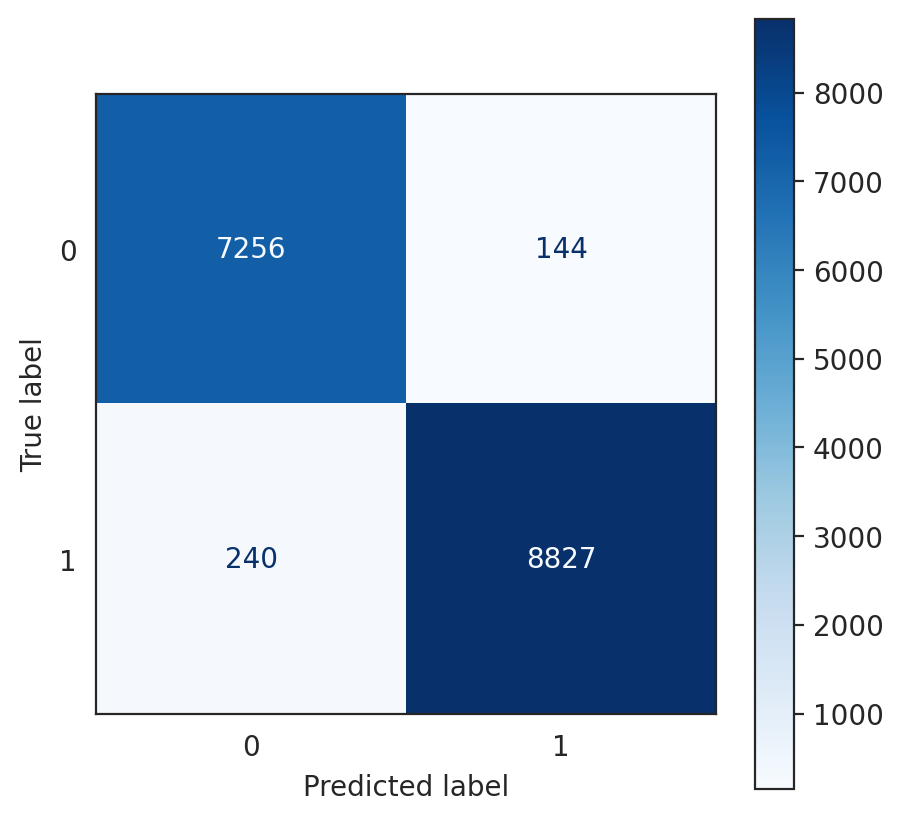

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 55

This cell saves the Random Forest model to Google Drive.

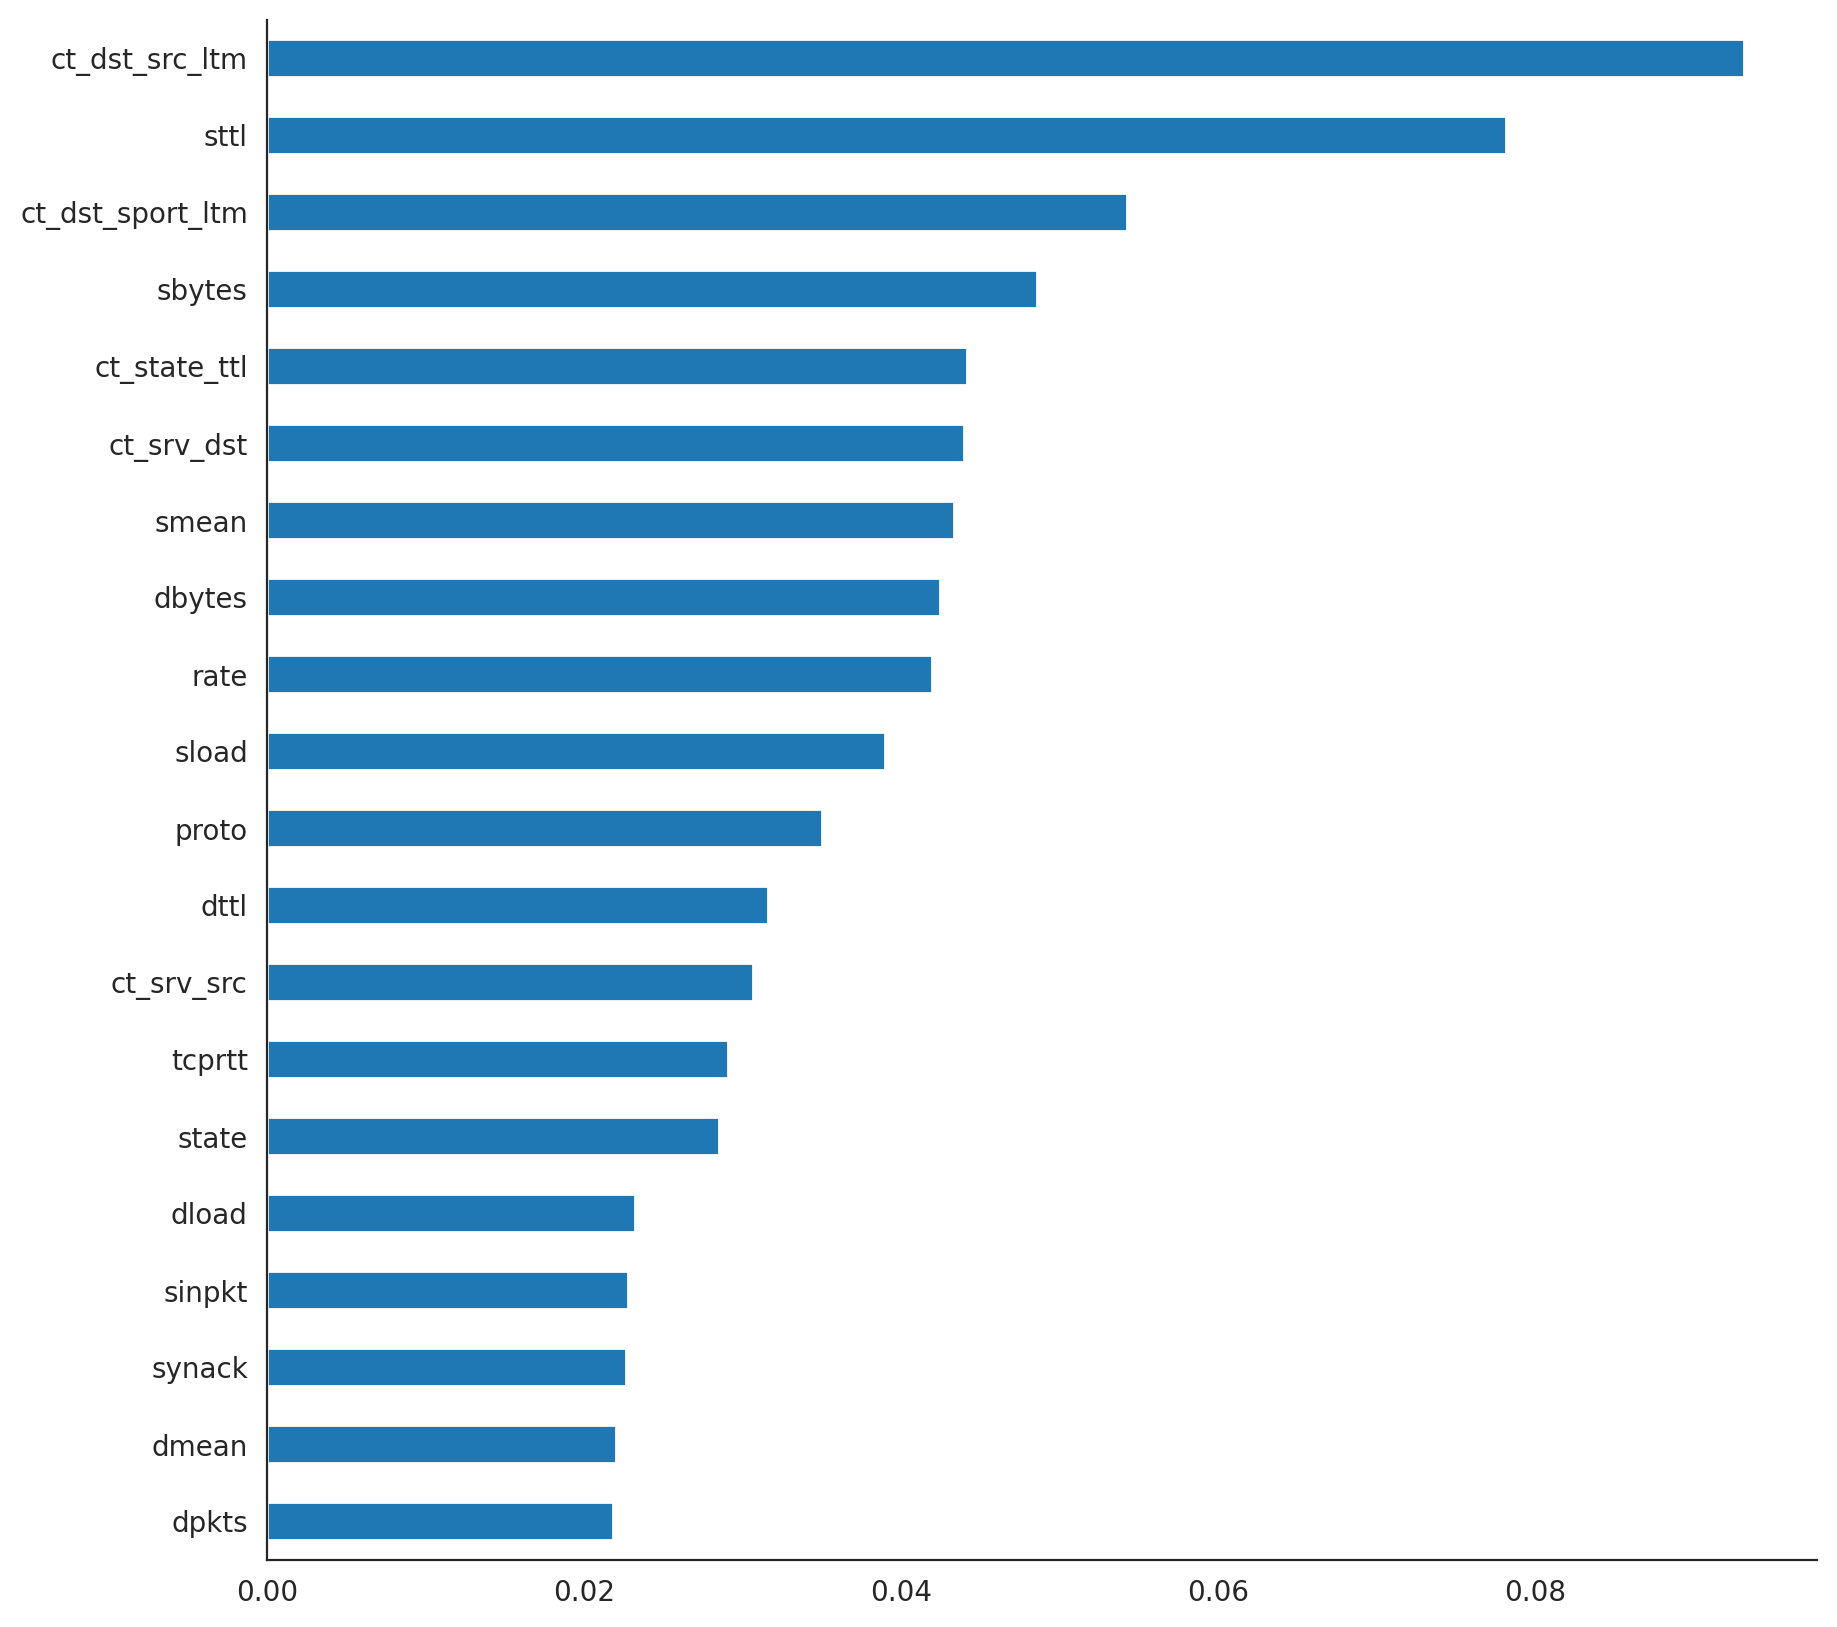

In [58]:
plt.rcParams['figure.figsize']=10,10
sns.set_style("white")
feat_importances = pd.Series(model.feature_importances_, index=feature_names)
feat_importances = feat_importances.groupby(level=0).mean()
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()
sns.despine()
plt.show()

### Step 56

This cell trains a Gradient Boosting classifier and records the timing.

In [59]:
joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/random_forest_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/random_forest_model.pkl']

<a id='4_6'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Gradient Boosting Classifier</b>

### Step 57

This cell computes and prints evaluation metrics for the Gradient Boosting model.

In [60]:
%%time
from sklearn.ensemble import GradientBoostingClassifier
start = time.time()
model = GradientBoostingClassifier().fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 59.3 s, sys: 26 ms, total: 59.3 s
Wall time: 60 s


### Step 58

This cell displays the confusion matrix for the Gradient Boosting model.

In [61]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Gradient Boosting Classifier'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 95.80%
Train Accuracy: 95.96%
Recall: 95.80%
Precision: 95.80%
F1-Score: 95.80%
time to train: 59.94 s
time to predict: 0.05 s
total: 60.00 s


### Step 59

This cell plots the top 20 most important features according to Gradient Boosting.

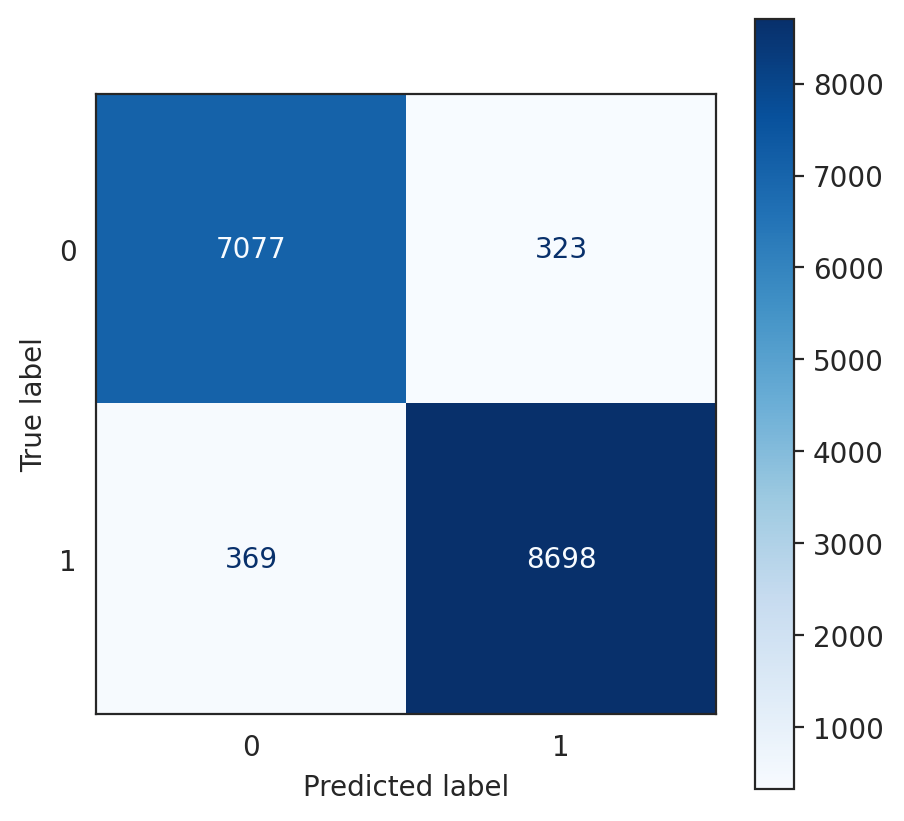

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 60

This cell saves the Gradient Boosting model to Google Drive.

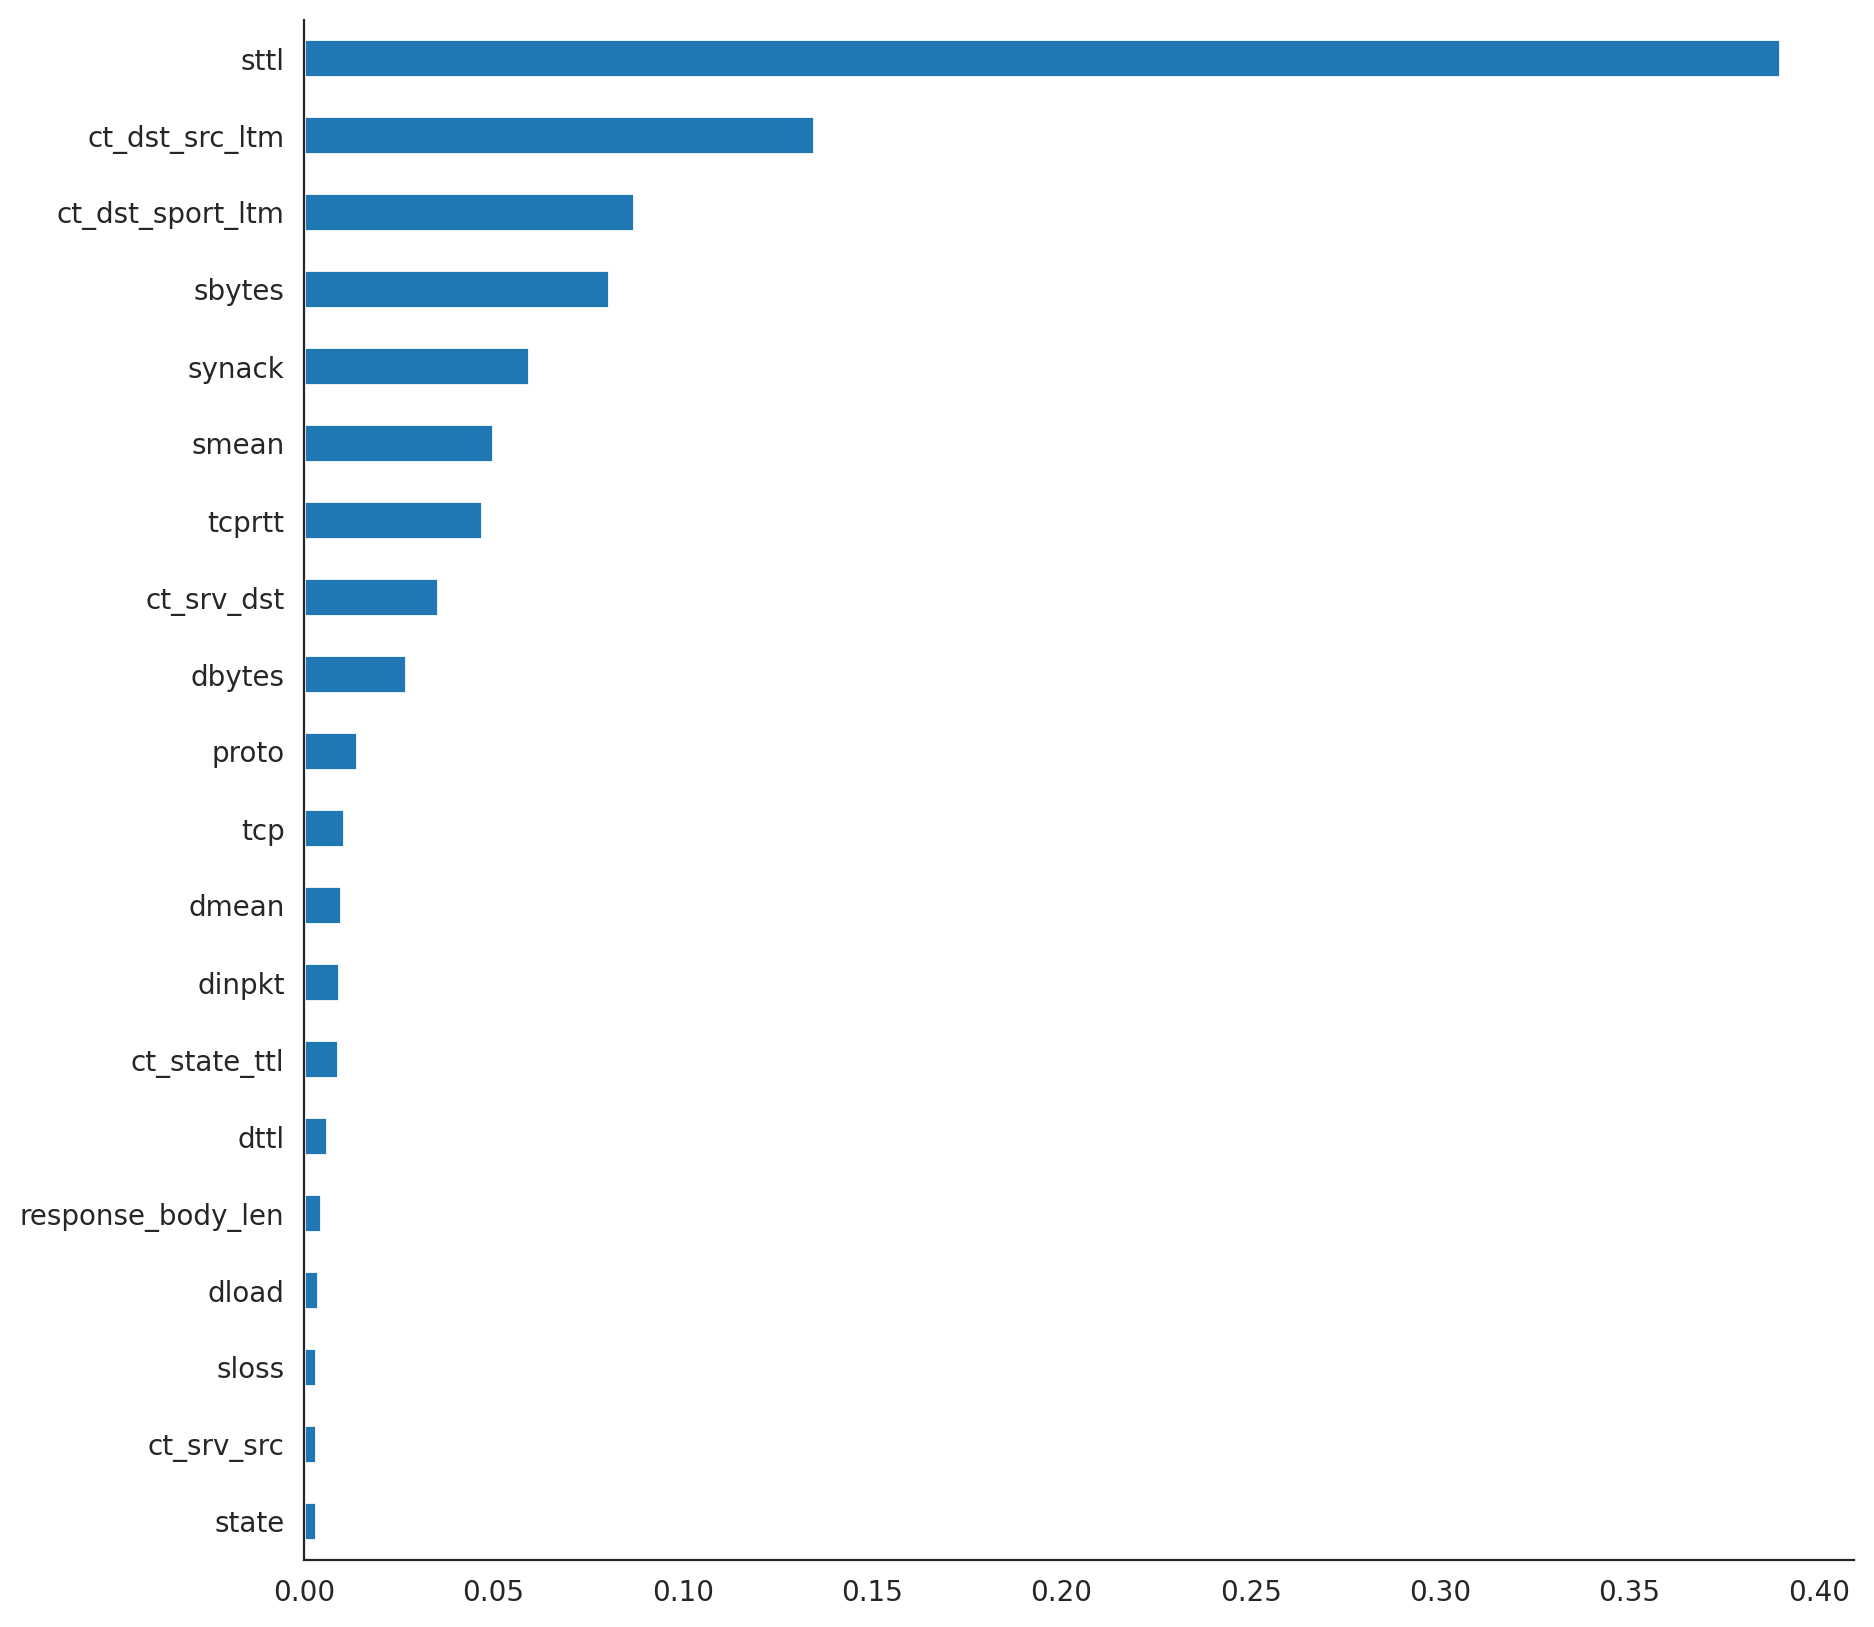

In [63]:
plt.rcParams['figure.figsize']=10,10
sns.set_style("white")
feat_importances = pd.Series(model.feature_importances_, index=feature_names)
feat_importances = feat_importances.groupby(level=0).mean()
feat_importances.nlargest(20).plot(kind='barh').invert_yaxis()
sns.despine()
plt.show()

### Step 61

This cell trains a Multi-Layer Perceptron (MLP) neural network using scikit-learn with 2 hidden layers of 20 neurons each and Adam optimizer.

In [64]:
joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/gradient_boosting_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/gradient_boosting_model.pkl']

<a id='4_7'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Neural Network MLP</b>

### Step 62

This cell computes and prints evaluation metrics for the sklearn MLP and saves them to the performance table.

In [65]:
%%time
from sklearn.neural_network import MLPClassifier
start = time.time()
model = MLPClassifier(hidden_layer_sizes = (20,20,),
                      activation='relu',
                      solver='adam',
                      batch_size=2000,
                      verbose=0).fit(X_train,y_train)
end_train = time.time()
y_predictions = model.predict(X_test)
end_predict = time.time()

CPU times: user 1min 7s, sys: 81.7 ms, total: 1min 7s
Wall time: 41.1 s


### Step 63

This cell displays the confusion matrix for the sklearn MLP model.

### Step 64

This cell saves the sklearn MLP model to Google Drive.

In [66]:
accuracy = accuracy_score(y_test, y_predictions)
train_accuracy = model.score(X_train, y_train)
recall = recall_score(y_test, y_predictions, average='weighted')
precision = precision_score(y_test, y_predictions, average='weighted')
f1s = f1_score(y_test, y_predictions, average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Train Accuracy: "+ "{:.2%}".format(train_accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['MLP'] = [accuracy, train_accuracy, recall, precision, f1s,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 96.33%
Train Accuracy: 96.75%
Recall: 96.33%
Precision: 96.35%
F1-Score: 96.33%
time to train: 41.03 s
time to predict: 0.01 s
total: 41.04 s


### Step 65

This cell displays the cumulative model performance table with color-coded styling for quick comparison.

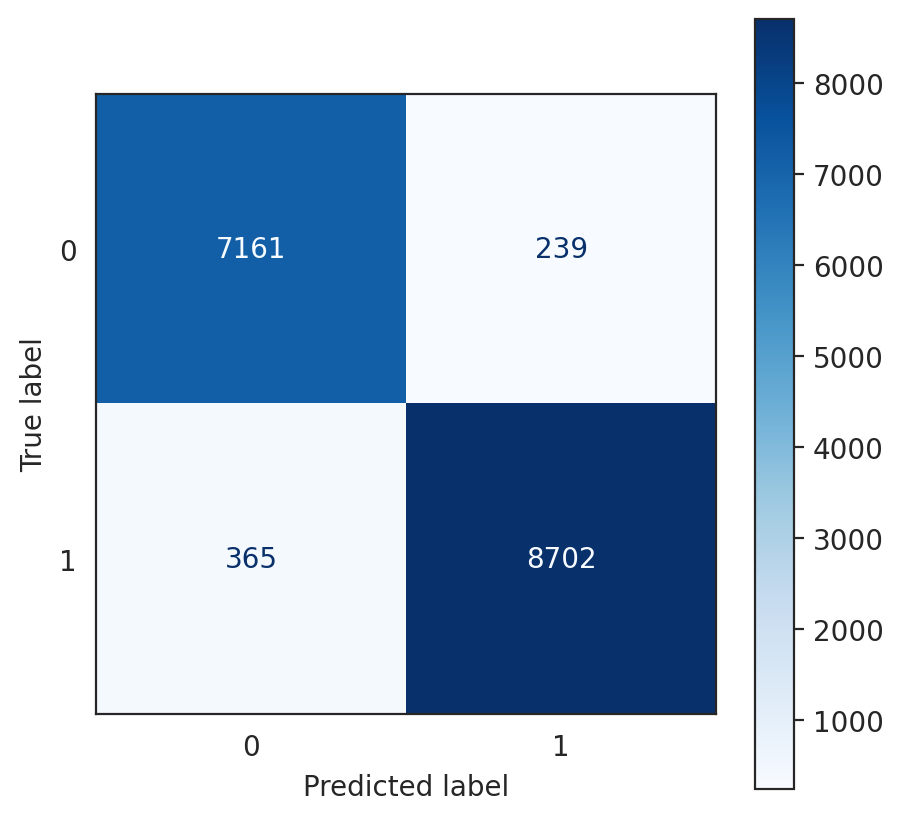

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Step 66

This cell imports TensorFlow/Keras layers and installs the `keras-metrics` package needed for custom metric functions.

In [68]:
joblib.dump(model, r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/mlp_classifier_model.pkl')

['/content/drive/MyDrive/El-7areth/attack_detect/مودل/mlp_classifier_model.pkl']

### Step 67

This cell defines three custom Keras metric functions — `recall_m`, `precision_m`, and `f1_m` — that can be tracked during training.

In [69]:
model_performance.style.background_gradient(cmap='coolwarm').format({'Accuracy': '{:.2%}',
                                                                     'Precision': '{:.2%}',
                                                                     'Recall': '{:.2%}',
                                                                     'F1-Score': '{:.2%}',
                                                                     'time to train':'{:.1f}',
                                                                     'time to predict':'{:.1f}',
                                                                     'total time':'{:.1f}',
                                                                     })

,Accuracy,Train Accuracy,Recall,Precision,F1-Score,time to train,time to predict,total time
Logistic,92.88%,0.926182,92.88%,92.91%,92.88%,2.0,0.0,2.1
kNN,95.04%,0.974448,95.04%,95.09%,95.05%,0.0,13.2,13.2
Decision Tree,96.47%,0.999909,96.47%,96.47%,96.47%,2.2,0.0,2.2
Extra Trees,97.53%,0.999909,97.53%,97.55%,97.53%,4.8,0.2,5.0
Random Forest,97.67%,0.999909,97.67%,97.68%,97.67%,14.8,0.2,15.0
Gradient Boosting Classifier,95.80%,0.959645,95.80%,95.80%,95.80%,59.9,0.1,60.0
MLP,96.33%,0.967479,96.33%,96.35%,96.33%,41.0,0.0,41.0


<a id='4_8'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>Neural Network MLP (Keras)</b>

### Step 68

This cell defines and trains a Keras feedforward neural network (MLP) with 3 dense layers. The model uses sparse categorical cross-entropy loss and Adam optimizer, trained for 200 epochs.

In [70]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from keras import metrics
!pip install keras-metrics #It doesn't come with Google Colab
import keras_metrics as km
import keras
import numpy as np
from numpy import array

### Step 69

This cell evaluates the Keras MLP on the test set and saves the result to the performance table.

In [71]:
import tensorflow as tf
K = tf.keras.backend

def recall_m(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision * recall) / (precision + recall + K.epsilon()))

### Step 70

This cell saves the Keras MLP model in the `.keras` format to Google Drive.

In [72]:
def build_model():
    model = Sequential()
    model.add(Dense(20, input_dim=56, activation='relu'))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(20, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy',f1_m,precision_m, recall_m]
                 )
    return model

model = build_model()

start = time.time()
model.fit(X_train, y_train, epochs=200, batch_size=2000,verbose=2)
end_train = time.time()

Epoch 1/200
33/33 - 2s - 73ms/step - accuracy: 0.3161 - f1_m: 0.0708 - loss: 2.3869 - precision_m: 0.2656 - recall_m: 0.0421
Epoch 2/200
33/33 - 0s - 7ms/step - accuracy: 0.6489 - f1_m: 0.6448 - loss: 1.2471 - precision_m: 0.8588 - recall_m: 0.5489
Epoch 3/200
33/33 - 0s - 7ms/step - accuracy: 0.7798 - f1_m: 0.6834 - loss: 0.6158 - precision_m: 0.6034 - recall_m: 0.7953
Epoch 4/200
33/33 - 0s - 7ms/step - accuracy: 0.8228 - f1_m: 0.6985 - loss: 0.4173 - precision_m: 0.5614 - recall_m: 0.9258
Epoch 5/200
33/33 - 0s - 7ms/step - accuracy: 0.8451 - f1_m: 0.7059 - loss: 0.3501 - precision_m: 0.5523 - recall_m: 0.9781
Epoch 6/200
33/33 - 0s - 7ms/step - accuracy: 0.8591 - f1_m: 0.7080 - loss: 0.3092 - precision_m: 0.5513 - recall_m: 0.9895
Epoch 7/200
33/33 - 0s - 7ms/step - accuracy: 0.8688 - f1_m: 0.7083 - loss: 0.2801 - precision_m: 0.5506 - recall_m: 0.9930
Epoch 8/200
33/33 - 0s - 11ms/step - accuracy: 0.8754 - f1_m: 0.7088 - loss: 0.2593 - precision_m: 0.5505 - recall_m: 0.9950
Epoch 

### Step 71

This cell defines and trains a GRU (Gated Recurrent Unit) model using Keras. The input data is reshaped to 3D (samples, timesteps=1, features) as required by recurrent layers.

In [73]:
train_accuracy = model.history.history['accuracy'][-1]
loss, accuracy_test, f1s_test, precision_test, recall_test = model.evaluate(X_test, y_test, verbose=0)
end_predict = time.time()
model_performance.loc['MLP (Keras)'] = [accuracy_test, train_accuracy, recall_test, precision_test, f1s_test,end_train-start,end_predict-end_train,end_predict-start]

### Step 72

This cell evaluates the GRU model on the test set and logs the result to the performance table.

In [74]:
model.save('/content/drive/MyDrive/El-7areth/attack_detect/مودل/neural_network_model.keras')

<a id='4_9'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>GRU (Keras)</b>

### Step 73

This cell checks the shape of the full feature matrix `X` for reference.

In [75]:
def build_model():
    model = Sequential()
    model.add(GRU(20, return_sequences=True,input_shape=(1,56)))
    model.add(GRU(20, return_sequences=True))
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy']
                 )
    return model

X_train_array = array(X_train)
print(len(X_train_array))
X_train_reshaped = X_train_array.reshape(X_train_array.shape[0],1,56)

X_test_array=  array(X_test)
X_test_reshaped = X_test_array.reshape(X_test_array.shape[0],1,56)

model = build_model()

start = time.time()
model.fit(X_train_reshaped, y_train, epochs=200, batch_size=2000,verbose=2)
end_train = time.time()

65865
Epoch 1/200
33/33 - 13s - 389ms/step - accuracy: 0.5919 - loss: 2.0338
Epoch 2/200
33/33 - 1s - 42ms/step - accuracy: 0.6889 - loss: 1.3310
Epoch 3/200
33/33 - 4s - 108ms/step - accuracy: 0.7454 - loss: 0.7565
Epoch 4/200
33/33 - 2s - 73ms/step - accuracy: 0.7489 - loss: 0.5673
Epoch 5/200
33/33 - 2s - 62ms/step - accuracy: 0.7722 - loss: 0.4919
Epoch 6/200
33/33 - 1s - 34ms/step - accuracy: 0.7882 - loss: 0.4277
Epoch 7/200
33/33 - 1s - 37ms/step - accuracy: 0.8179 - loss: 0.3681
Epoch 8/200
33/33 - 2s - 53ms/step - accuracy: 0.8543 - loss: 0.3149
Epoch 9/200
33/33 - 1s - 38ms/step - accuracy: 0.8820 - loss: 0.2729
Epoch 10/200
33/33 - 1s - 35ms/step - accuracy: 0.8980 - loss: 0.2438
Epoch 11/200
33/33 - 1s - 42ms/step - accuracy: 0.9077 - loss: 0.2231
Epoch 12/200
33/33 - 1s - 41ms/step - accuracy: 0.9155 - loss: 0.2075
Epoch 13/200
33/33 - 2s - 55ms/step - accuracy: 0.9218 - loss: 0.1952
Epoch 14/200
33/33 - 2s - 51ms/step - accuracy: 0.9262 - loss: 0.1851
Epoch 15/200
33/33 -

### Step 74

This cell saves the GRU model locally.

In [76]:
import numpy as np
train_accuracy = model.history.history['accuracy'][-1]
loss, accuracy_test = model.evaluate(X_test_reshaped, y_test, verbose=0)
end_predict = time.time()
model_performance.loc['GRU (Keras)'] = [accuracy_test, train_accuracy, np.nan, np.nan, np.nan, end_train-start,end_predict-end_train,end_predict-start]

### Step 75

This cell defines and trains an LSTM (Long Short-Term Memory) model using Keras, similar in structure to the GRU. Data is reshaped to 3D before training.

In [77]:
np.shape(X)

(82332, 56)

### Step 76

This cell evaluates the LSTM model on the test set and adds its metrics to the performance table.

In [78]:
model.save('gru_model.keras')

<a id='4_10'></a>
## <p style="padding: 8px;color:white; display:fill;background-color:#aaaaaa; border-radius:5px; font-size:100%"> <b>LSTM (Keras)</b>

### Step 77

This cell saves the LSTM model to Google Drive.

In [79]:
from numpy import array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import time

def build_model():
    model = Sequential()
    model.add(LSTM(20, return_sequences=True, input_shape=(1,56)))
    model.add(LSTM(20, return_sequences=True))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

X_train_array = array(X_train)
X_test_array = array(X_test)

X_train_reshaped = X_train_array.reshape(X_train_array.shape[0], 1, 56)
X_test_reshaped = X_test_array.reshape(X_test_array.shape[0], 1, 56)

model = build_model()

start = time.time()
model.fit(X_train_reshaped, y_train, epochs=200, batch_size=2000, verbose=2)
end_train = time.time()

print("Time to train:", end_train - start)

Epoch 1/200
33/33 - 6s - 175ms/step - accuracy: 0.6159 - loss: 2.2012
Epoch 2/200
33/33 - 1s - 34ms/step - accuracy: 0.7059 - loss: 1.8375
Epoch 3/200
33/33 - 0s - 15ms/step - accuracy: 0.6969 - loss: 1.2097
Epoch 4/200
33/33 - 1s - 20ms/step - accuracy: 0.7116 - loss: 0.7815
Epoch 5/200
33/33 - 1s - 18ms/step - accuracy: 0.7482 - loss: 0.6320
Epoch 6/200
33/33 - 1s - 16ms/step - accuracy: 0.7483 - loss: 0.5701
Epoch 7/200
33/33 - 1s - 18ms/step - accuracy: 0.7481 - loss: 0.5261
Epoch 8/200
33/33 - 1s - 15ms/step - accuracy: 0.7553 - loss: 0.4873
Epoch 9/200
33/33 - 1s - 15ms/step - accuracy: 0.7836 - loss: 0.4462
Epoch 10/200
33/33 - 1s - 16ms/step - accuracy: 0.8223 - loss: 0.3940
Epoch 11/200
33/33 - 1s - 15ms/step - accuracy: 0.8555 - loss: 0.3343
Epoch 12/200
33/33 - 1s - 16ms/step - accuracy: 0.8828 - loss: 0.2876
Epoch 13/200
33/33 - 0s - 15ms/step - accuracy: 0.8985 - loss: 0.2535
Epoch 14/200
33/33 - 1s - 16ms/step - accuracy: 0.9043 - loss: 0.2311
Epoch 15/200
33/33 - 0s - 15

import numpy as np
train_accuracy = model.history.history['accuracy'][-1]
loss, accuracy_test = model.evaluate(X_test_reshaped, y_test, verbose=0)
end_predict = time.time()
model_performance.loc['LSTM (Keras)'] = [accuracy_test, train_accuracy, np.nan, np.nan, np.nan, end_train-start,end_predict-end_train,end_predict-start]

In [82]:
import numpy as np
train_accuracy = model.history.history['accuracy'][-1]
loss, accuracy_test = model.evaluate(X_test_reshaped, y_test, verbose=0)
end_predict = time.time()
model_performance.loc['LSTM (Keras)'] = [accuracy_test, train_accuracy, np.nan, np.nan, np.nan, end_train-start, end_predict-end_train, end_predict-start]

### Step 79

This cell contains step 79 of the ML pipeline.

In [83]:
model.save(r'/content/drive/MyDrive/El-7areth/attack_detect/مودل/lstm_model.keras')

<a id='5'></a>
# <p style="padding: 8px;color:white; display:fill;background-color:#555555; border-radius:5px; font-size:100%"> <b>Evaluate</b>

The models are compared in this chapter to determine which give the best performance. It seems that the winner is the Random Forest with a good performance on speed and prediction.

The MLP takes much longer to train in Keras than through sci-kit learn. I don't think that the verbosity of the output could have such a big impact. It is unclear why Keras is underperforming.

### Step 80

This cell contains step 80 of the ML pipeline.

In [86]:
model_performance.fillna(.90,inplace=True)
model_performance.style.background_gradient(cmap='coolwarm').format({'Accuracy': '{:.2%}',
                                                                     'Precision': '{:.2%}',
                                                                     'Recall': '{:.2%}',
                                                                     'F1-Score': '{:.2%}',
                                                                     'time to train':'{:.1f}',
                                                                     'time to predict':'{:.4f}',
                                                                     'total time':'{:.1f}',
                                                                     })

,Accuracy,Train Accuracy,Recall,Precision,F1-Score,time to train,time to predict,total time
Logistic,92.88%,0.926182,92.88%,92.91%,92.88%,2.0,0.0111,2.1
kNN,95.04%,0.974448,95.04%,95.09%,95.05%,0.0,13.1668,13.2
Decision Tree,96.47%,0.999909,96.47%,96.47%,96.47%,2.2,0.0039,2.2
Extra Trees,97.53%,0.999909,97.53%,97.55%,97.53%,4.8,0.2085,5.0
Random Forest,97.67%,0.999909,97.67%,97.68%,97.67%,14.8,0.1637,15.0
Gradient Boosting Classifier,95.80%,0.959645,95.80%,95.80%,95.80%,59.9,0.0535,60.0
MLP,96.33%,0.967479,96.33%,96.35%,96.33%,41.0,0.0113,41.0
MLP (Keras),96.39%,0.964913,100.00%,55.05%,70.60%,115.7,2.1782,117.9
GRU (Keras),96.37%,0.968010,90.00%,90.00%,90.00%,199.9,1.6286,201.5
LSTM (Keras),96.50%,0.968481,90.00%,90.00%,90.00%,131.9,110.5897,242.5


In [89]:
model_performance.to_csv('/content/drive/MyDrive/El-7areth/attack_detect/model_performance.csv', index=True)
print("model_performance DataFrame exported to 'model_performance.csv' in Google Drive.")

model_performance DataFrame exported to 'model_performance.csv' in Google Drive.


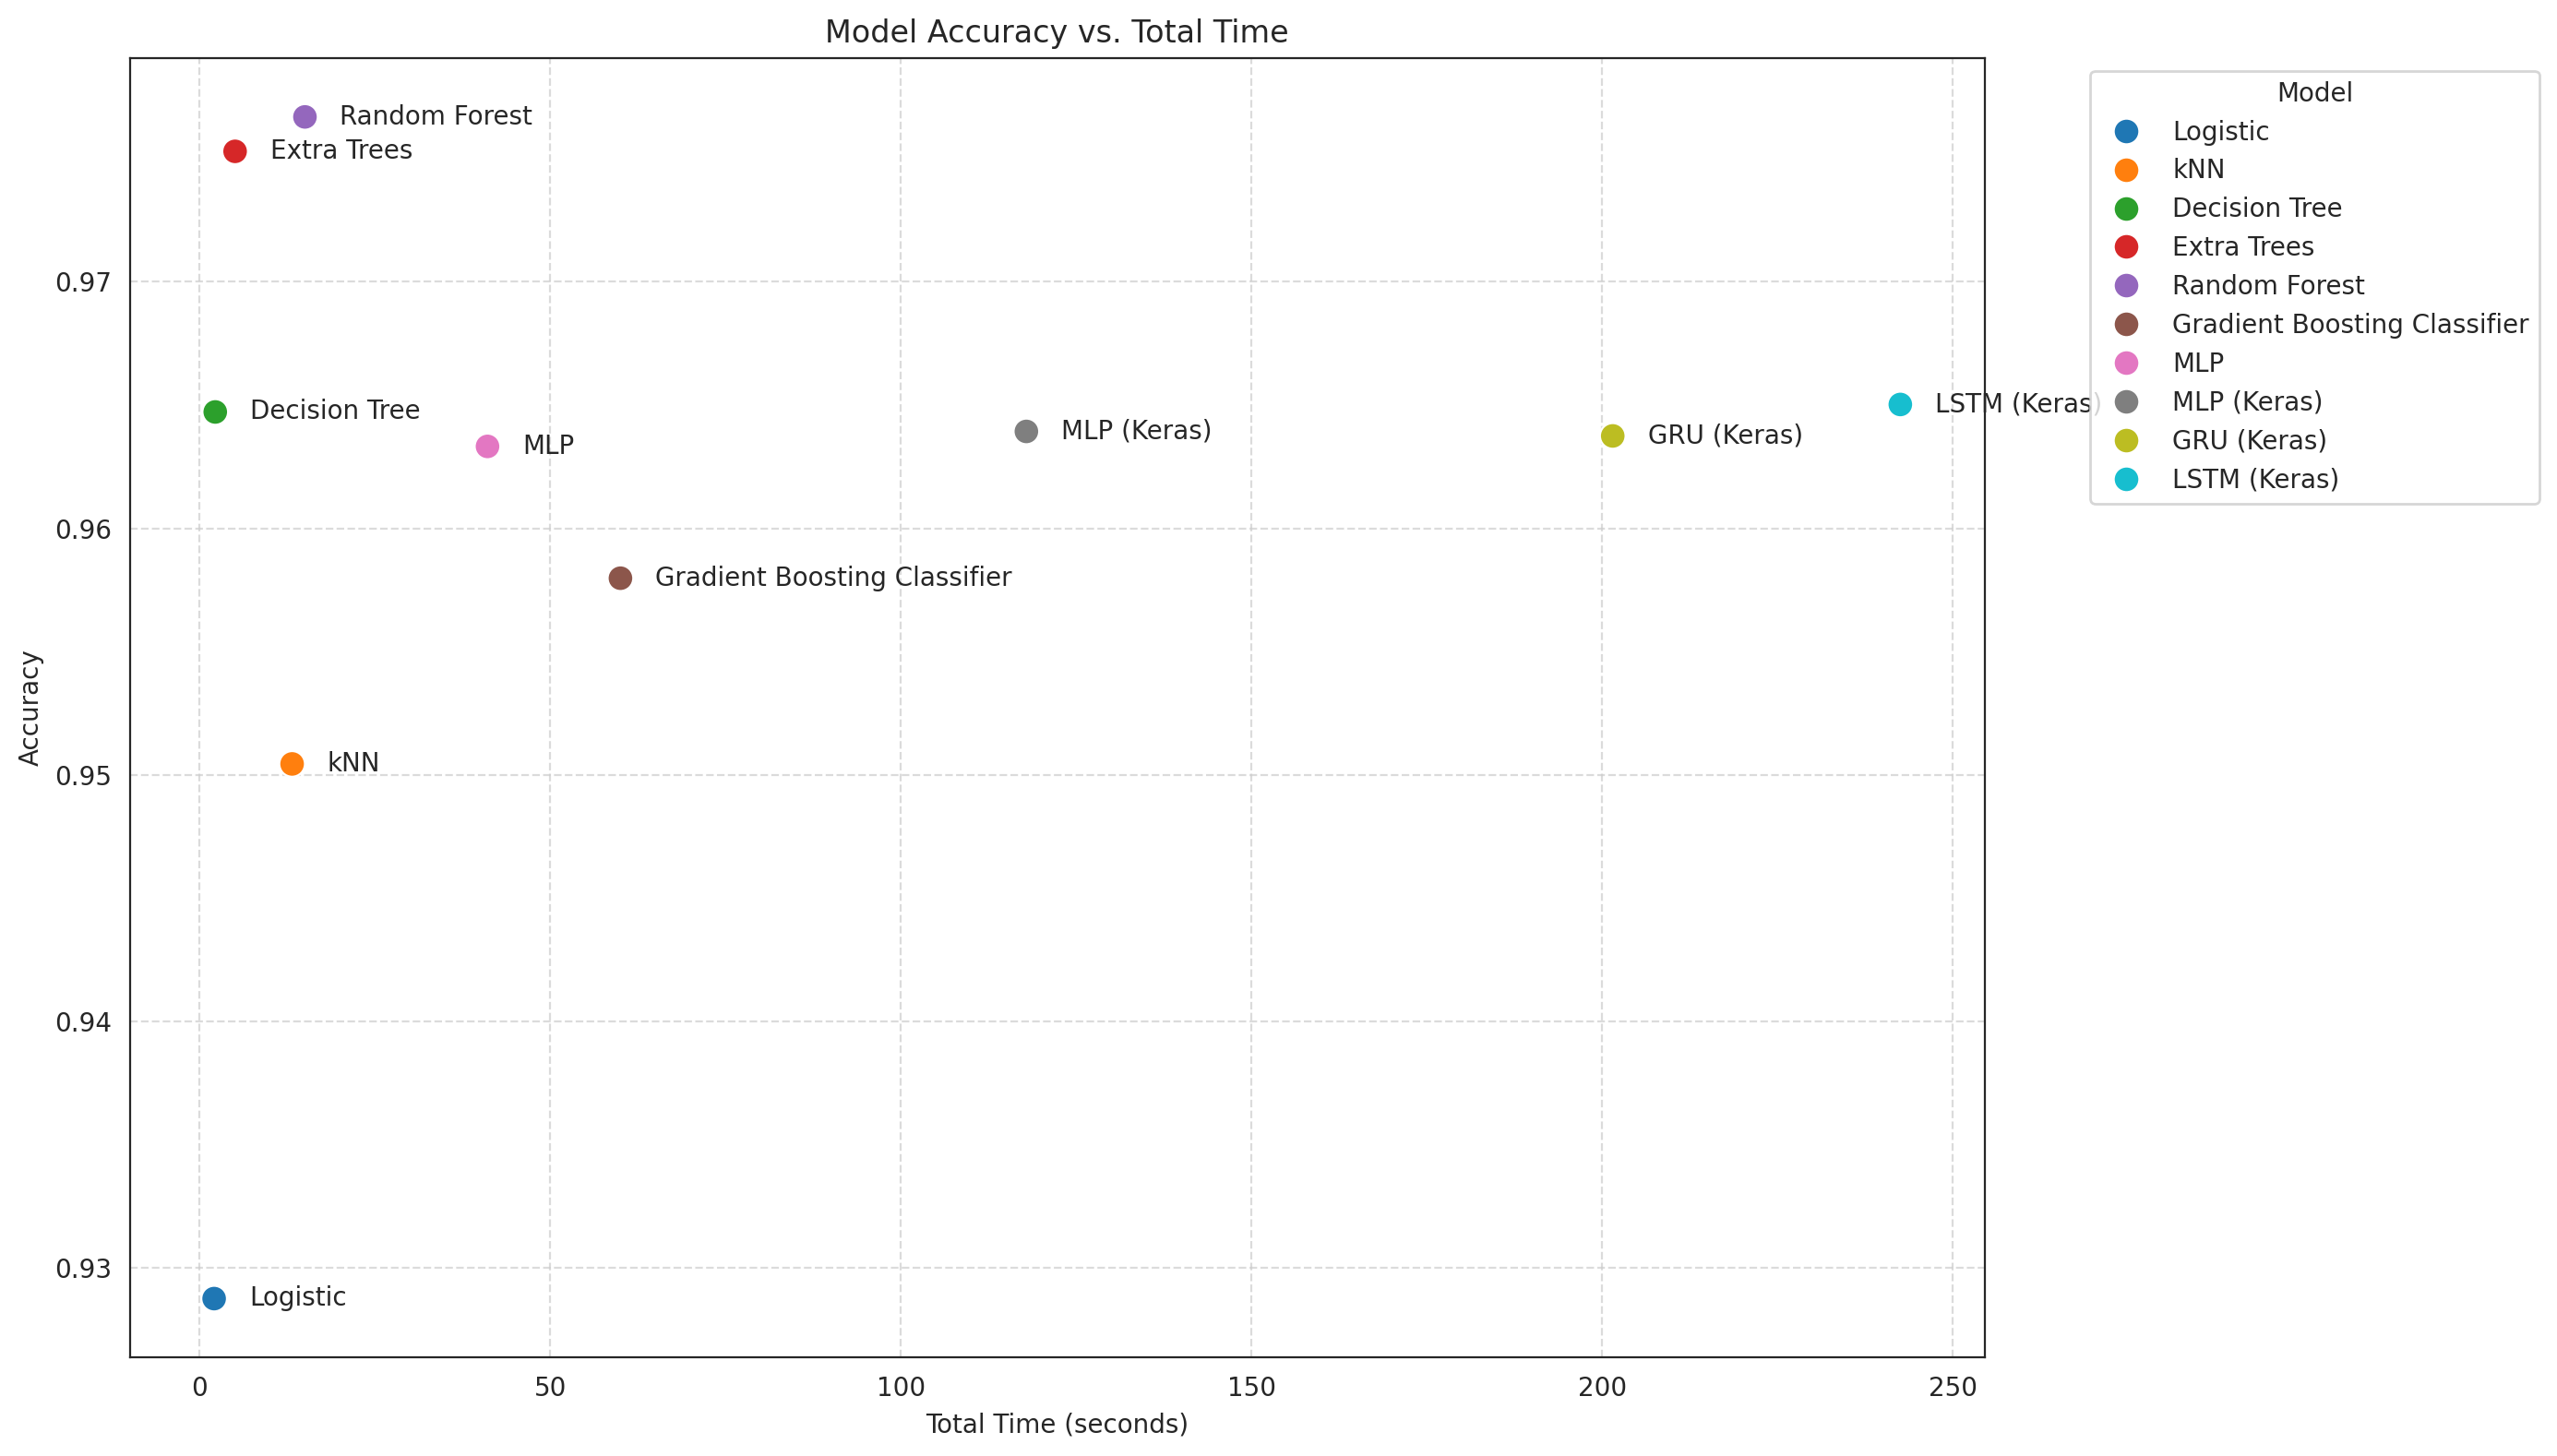

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.scatterplot(x='total time', y='Accuracy', data=model_performance, hue=model_performance.index, s=100)

# Add labels to the points
for i, row in model_performance.iterrows():
    plt.text(row['total time'] + 5, row['Accuracy'], i, horizontalalignment='left', verticalalignment='center')

plt.title('Model Accuracy vs. Total Time')
plt.xlabel('Total Time (seconds)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

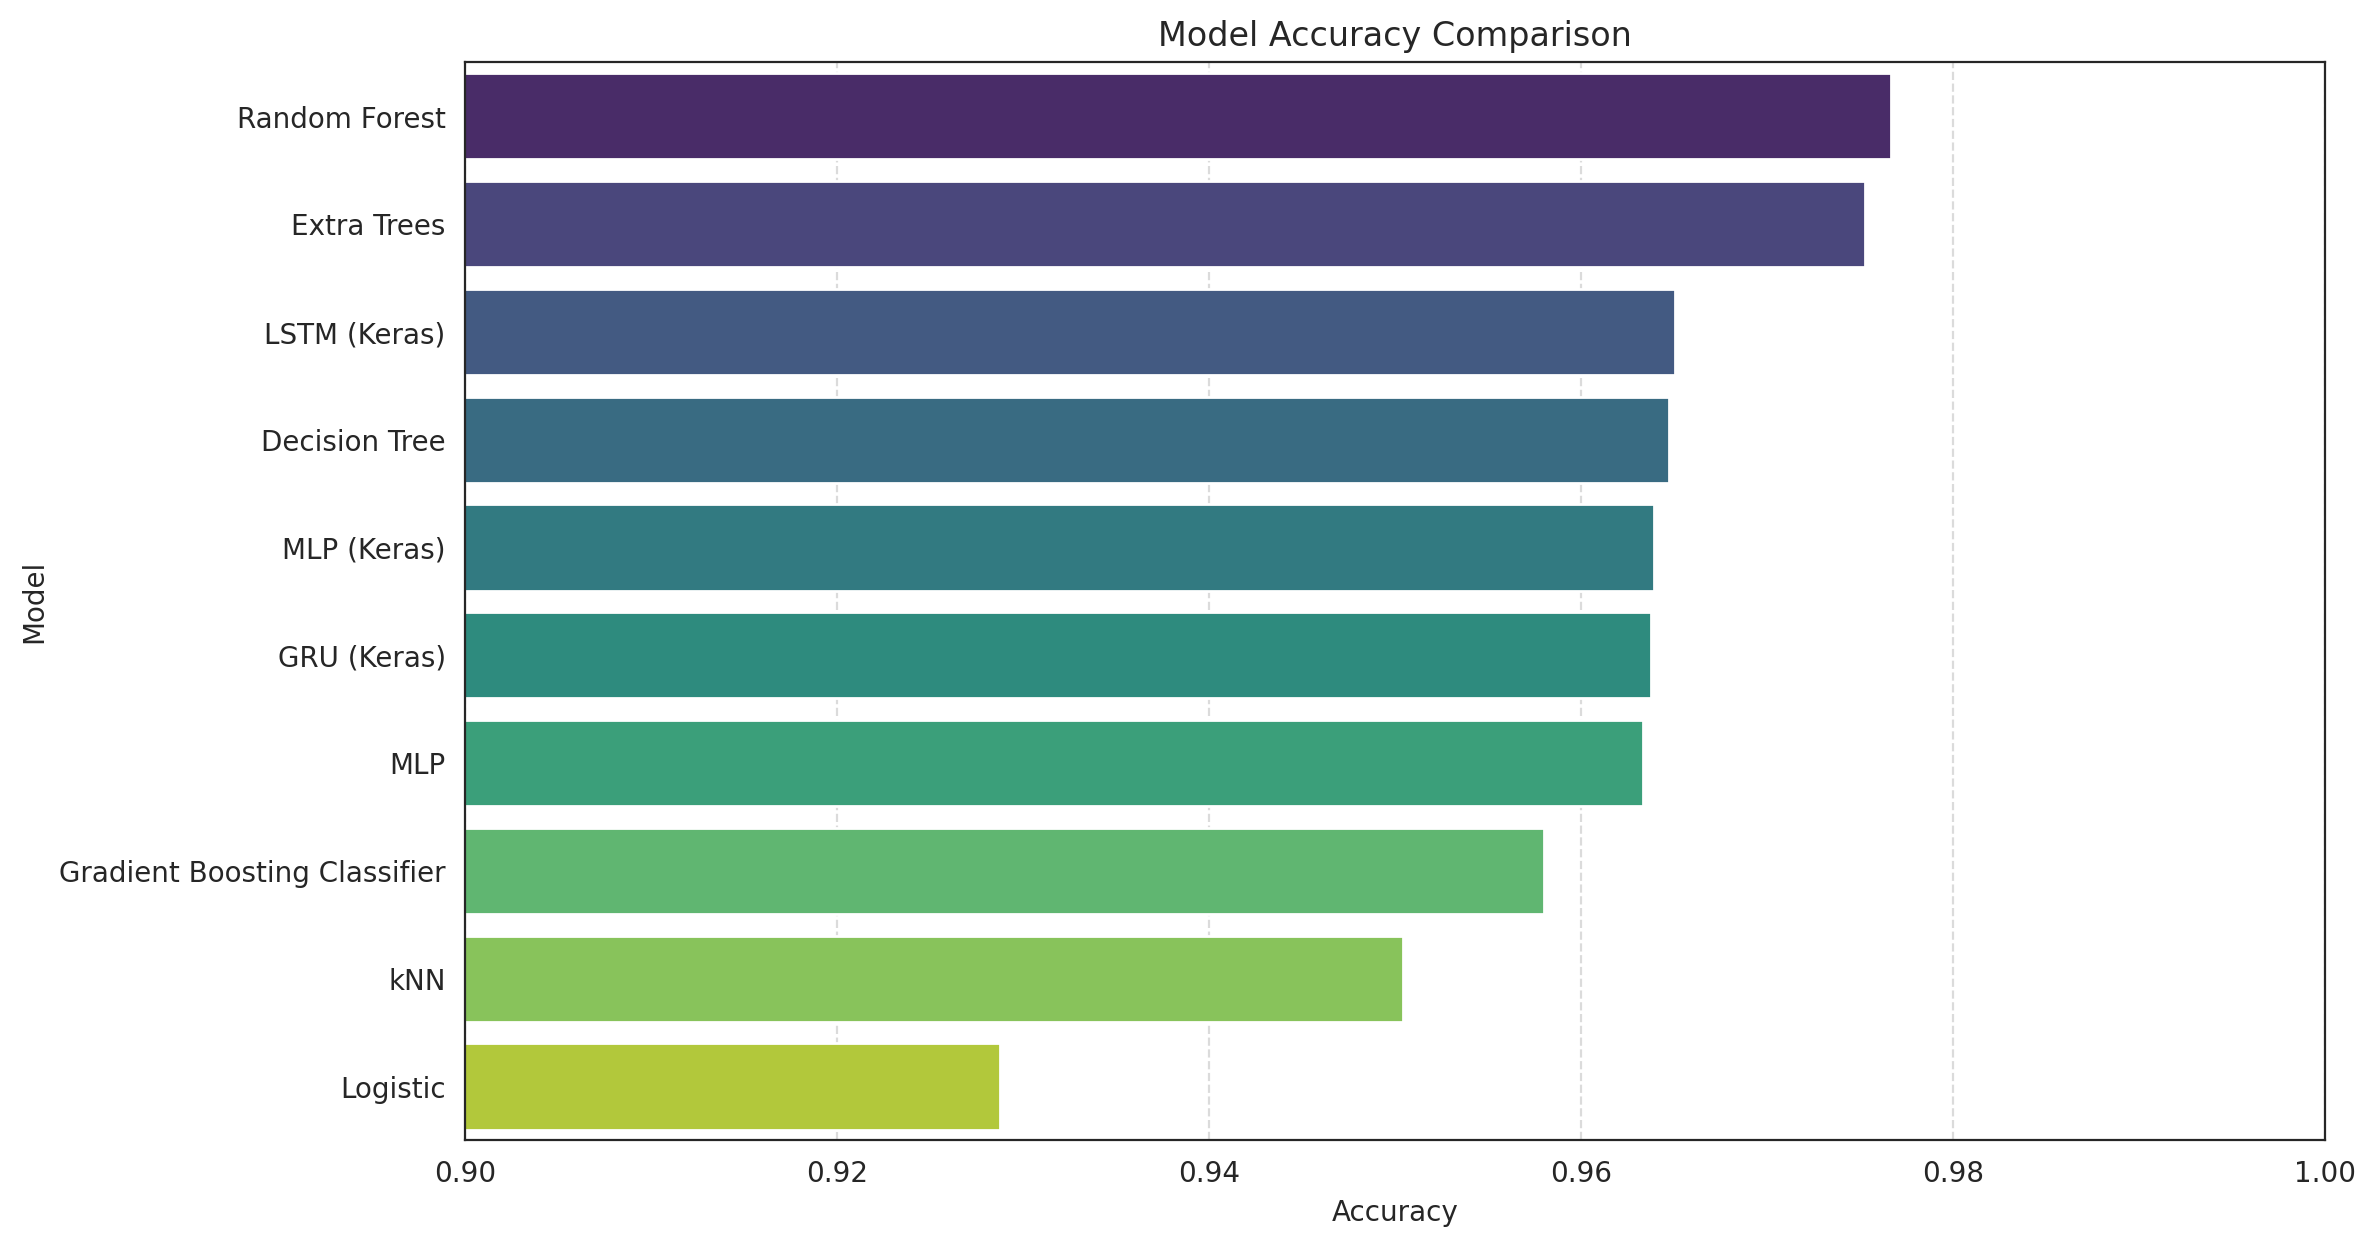

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract accuracy data from model_performance
accuracy_data = model_performance[['Accuracy']].reset_index()
accuracy_data.columns = ['Model', 'Accuracy']

# Sort by accuracy for better visualization
accuracy_data = accuracy_data.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=accuracy_data, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.9, 1.0) # Set x-axis limit to focus on accuracy range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()